# Data Visualisation in R
### *From Base Graphics to Publication-Quality ggplot2 Figures*

---

> *"The simple graph has brought more information to the data analyst's mind than any other device."*
> — John W. Tukey (1977), *Exploratory Data Analysis*

---

## Introduction

Data visualisation is not decoration — it is a **primary mode of scientific inference**. Well-constructed figures reveal distributional properties, relationships, outliers, and spatial patterns that summary statistics alone cannot convey (Anscombe, 1973; Tufte, 1983).

R is widely regarded as producing the finest statistical graphics of any programming environment. In this page, we explore two complementary approaches:

1. **Base R graphics** (`graphics` package): powerful, built-in, requiring no extra packages.
2. **`ggplot2`**: a principled, layered system based on Leland Wilkinson's *Grammar of Graphics* (2005), now the dominant tool for publication-quality figures in ecology and the biological sciences.

We will use the **Palmer Penguins** dataset throughout — the same dataset used in Part 1 and 2 — to maintain consistency and biological interpretability.

**References:**
- Anscombe, F.J. (1973). Graphs in statistical analysis. *The American Statistician*, 27(1), 17–21.
- Tufte, E.R. (1983). *The Visual Display of Quantitative Information*. Graphics Press.
- Wickham, H. (2010). A layered grammar of graphics. *Journal of Computational and Graphical Statistics*, 19(1), 3–28.
- Wilkinson, L. (2005). *The Grammar of Graphics* (2nd ed.). Springer.

---

## Setup

We begin every visualisation session by loading our packages and configuring the display for Jupyter notebooks (Skip `options()` chunk if you use RStudio or Base R).

In [1]:
suppressPackageStartupMessages({
    library(tidyverse)
    library(palmerpenguins)
})

# Configure plot output size for Jupyter / RMarkdown (Skip if using RStudio or Base R)
options(
  repr.plot.width  = 9,
  repr.plot.height = 6,
  repr.plot.res    = 180
)

# Load and prepare our consistent dataset
data("penguins")
penguins_complete <- penguins |> drop_na()

cat("Dataset: Palmer Penguins\n")
cat("Rows:", nrow(penguins_complete), "| Columns:", ncol(penguins_complete), "\n")
cat("Species:", paste(unique(penguins_complete$species), collapse = ", "), "\n")

Dataset: Palmer Penguins
Rows: 333 | Columns: 8 
Species: Adelie, Gentoo, Chinstrap 


---
## Base R Graphics

The `graphics` package is loaded automatically with R — no `library()` call needed. Base R graphics are **imperative**: you build a plot by issuing commands that add to the current graphics device. Each new function call either starts a new plot or adds elements to the existing one.

Base R is ideal for quick exploratory plots and is sufficient for many analytical purposes. Understanding it also highlights why `ggplot2` was designed the way it was.

### 1. Histograms

Histograms display the distribution of a single continuous variable. Plot histograms using `hist()`.

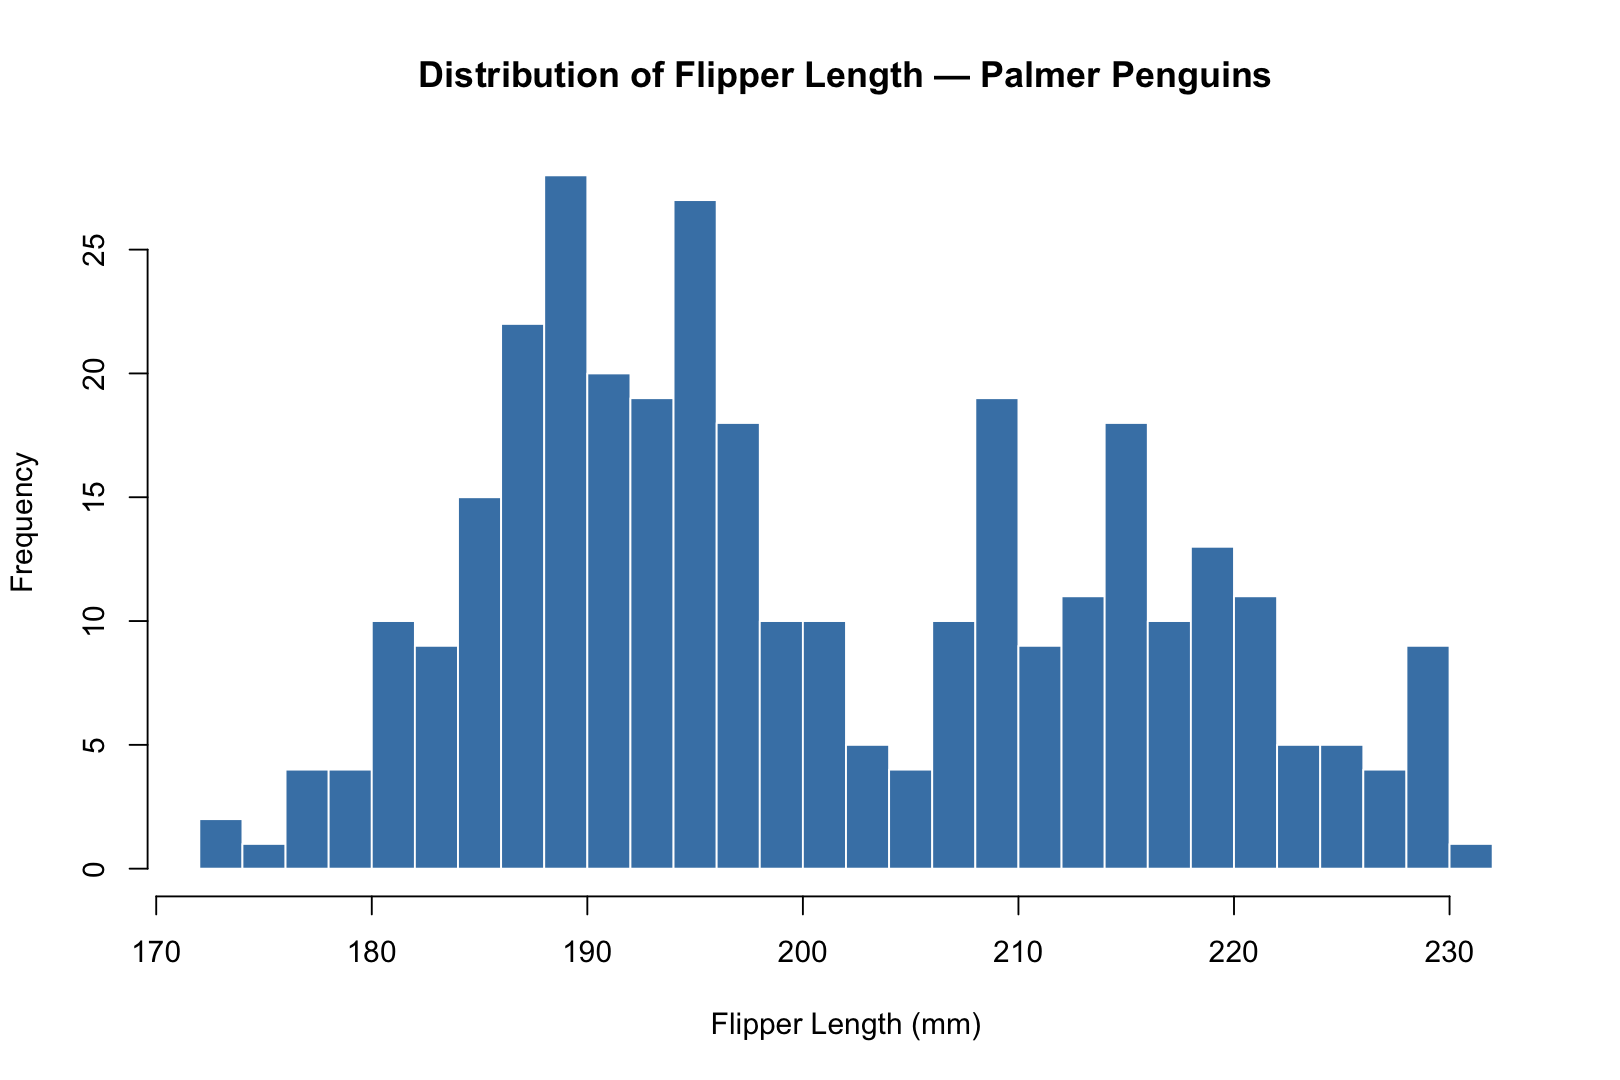

In [2]:
# A basic histogram of flipper length
hist(penguins_complete$flipper_length_mm,
     main  = "Distribution of Flipper Length — Palmer Penguins",
     xlab  = "Flipper Length (mm)",
     ylab  = "Frequency",
     col   = "steelblue",
     border= "white",
     breaks= 25)   # approximate number of bins

### 2. Scatter Plots

Scatter plots reveal relationships between two continuous variables.

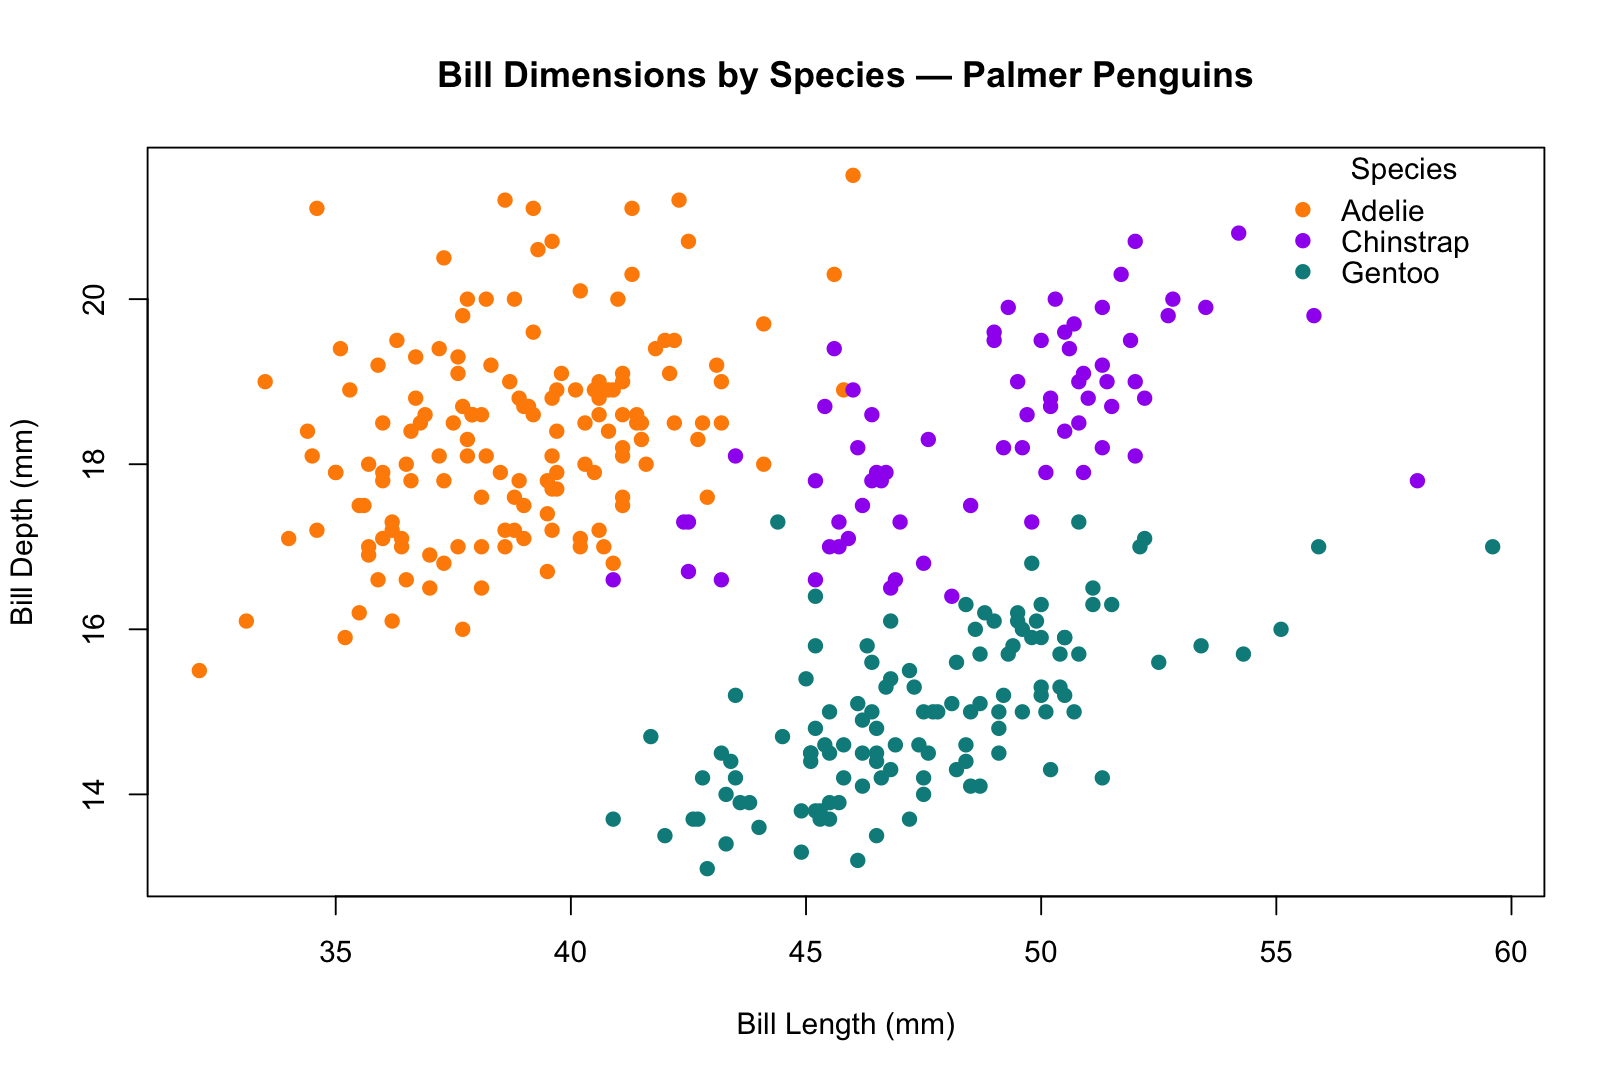

In [3]:
# Define species-specific colours (a standard palette in penguin research)
species_cols <- c("Adelie" = "darkorange", "Chinstrap" = "purple", "Gentoo" = "cyan4")

# Basic scatter plot
plot(x    = penguins_complete$bill_length_mm,
     y    = penguins_complete$bill_depth_mm,
     col  = species_cols[penguins_complete$species],
     pch  = 19,              # filled circle
     xlab = "Bill Length (mm)",
     ylab = "Bill Depth (mm)",
     main = "Bill Dimensions by Species — Palmer Penguins")

# Add a legend — this must be called AFTER plot()
legend("topright",
       legend = names(species_cols),
       col    = species_cols,
       pch    = 19,
       title  = "Species",
       bty    = "n")   # no box around the legend

### 3. Box Plots

Box plots (Tukey, 1977) display the five-number summary (minimum, Q1, median, Q3, maximum) and are particularly effective for comparing distributions across groups. Plot boxblots using `boxplot()`.

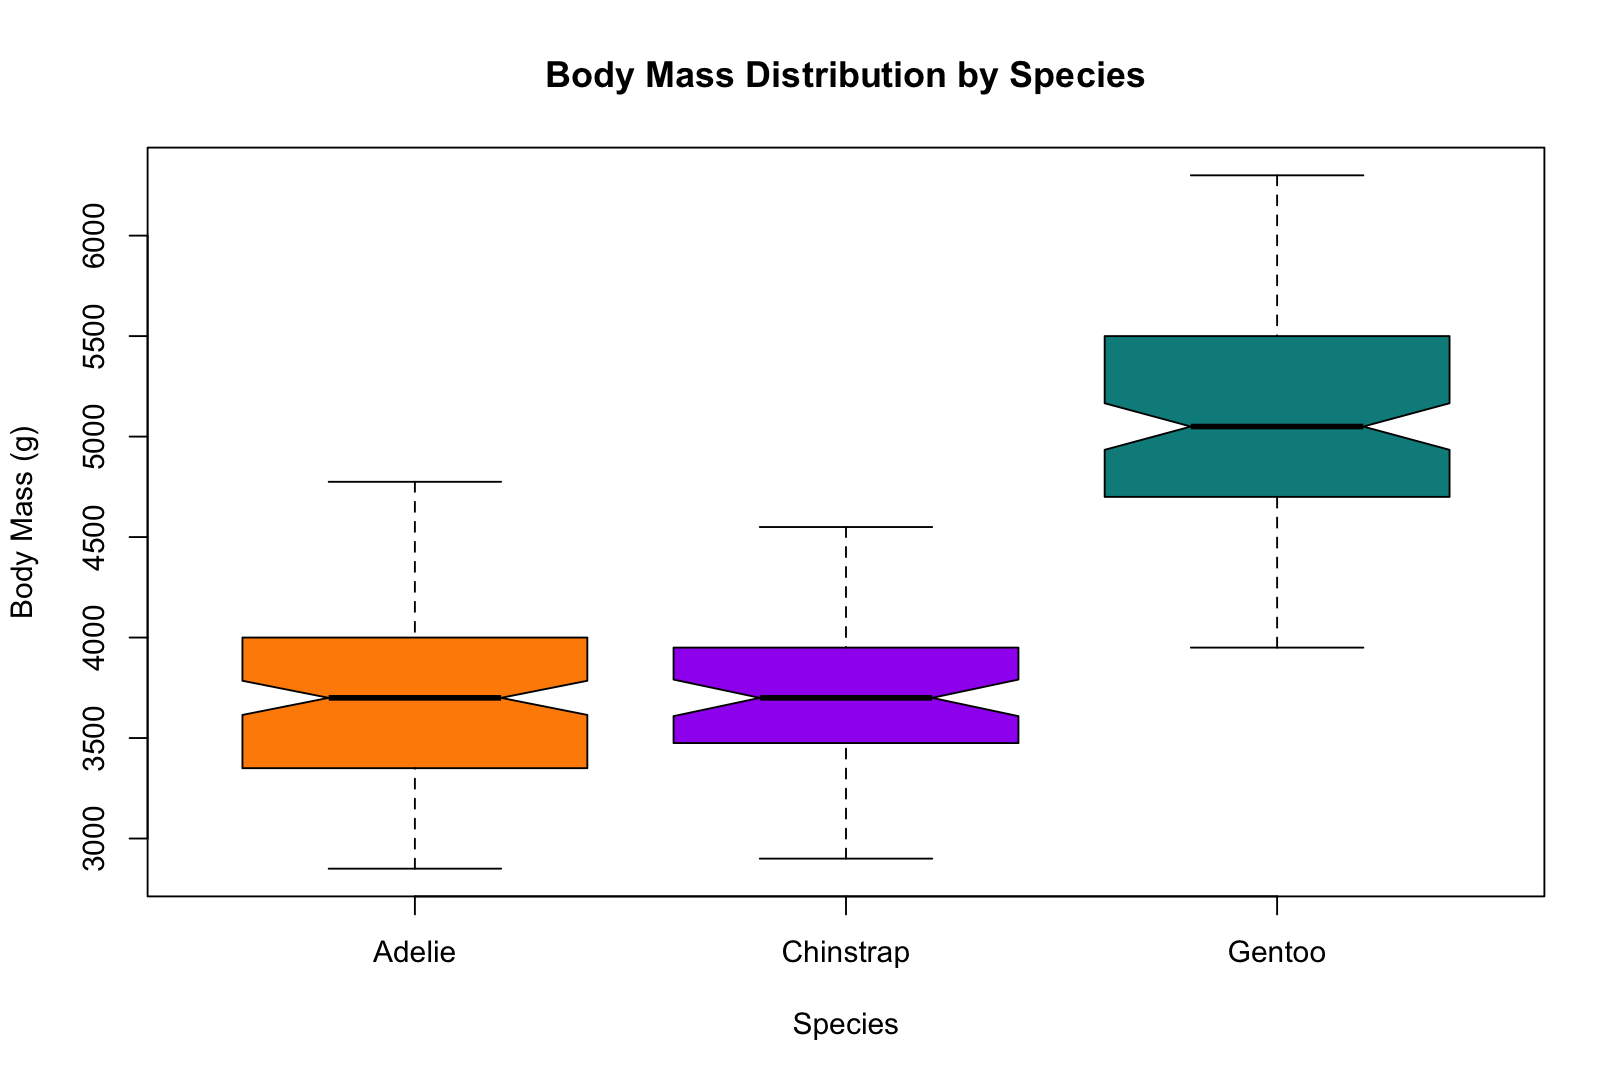

In [4]:
# Box plots — formula interface: response ~ group
boxplot(body_mass_g ~ species,
        data   = penguins_complete,
        col    = species_cols,
        xlab   = "Species",
        ylab   = "Body Mass (g)",
        main   = "Body Mass Distribution by Species",
        notch  = TRUE,   # notched boxes indicate 95% CI around the median
        outline= FALSE)  # suppress outlier points (cleaner for teaching)

### 4. Bar Plots

Bar plots summarise a categorical relationship. In base R, `barplot()` expects a table or matrix, not raw data.

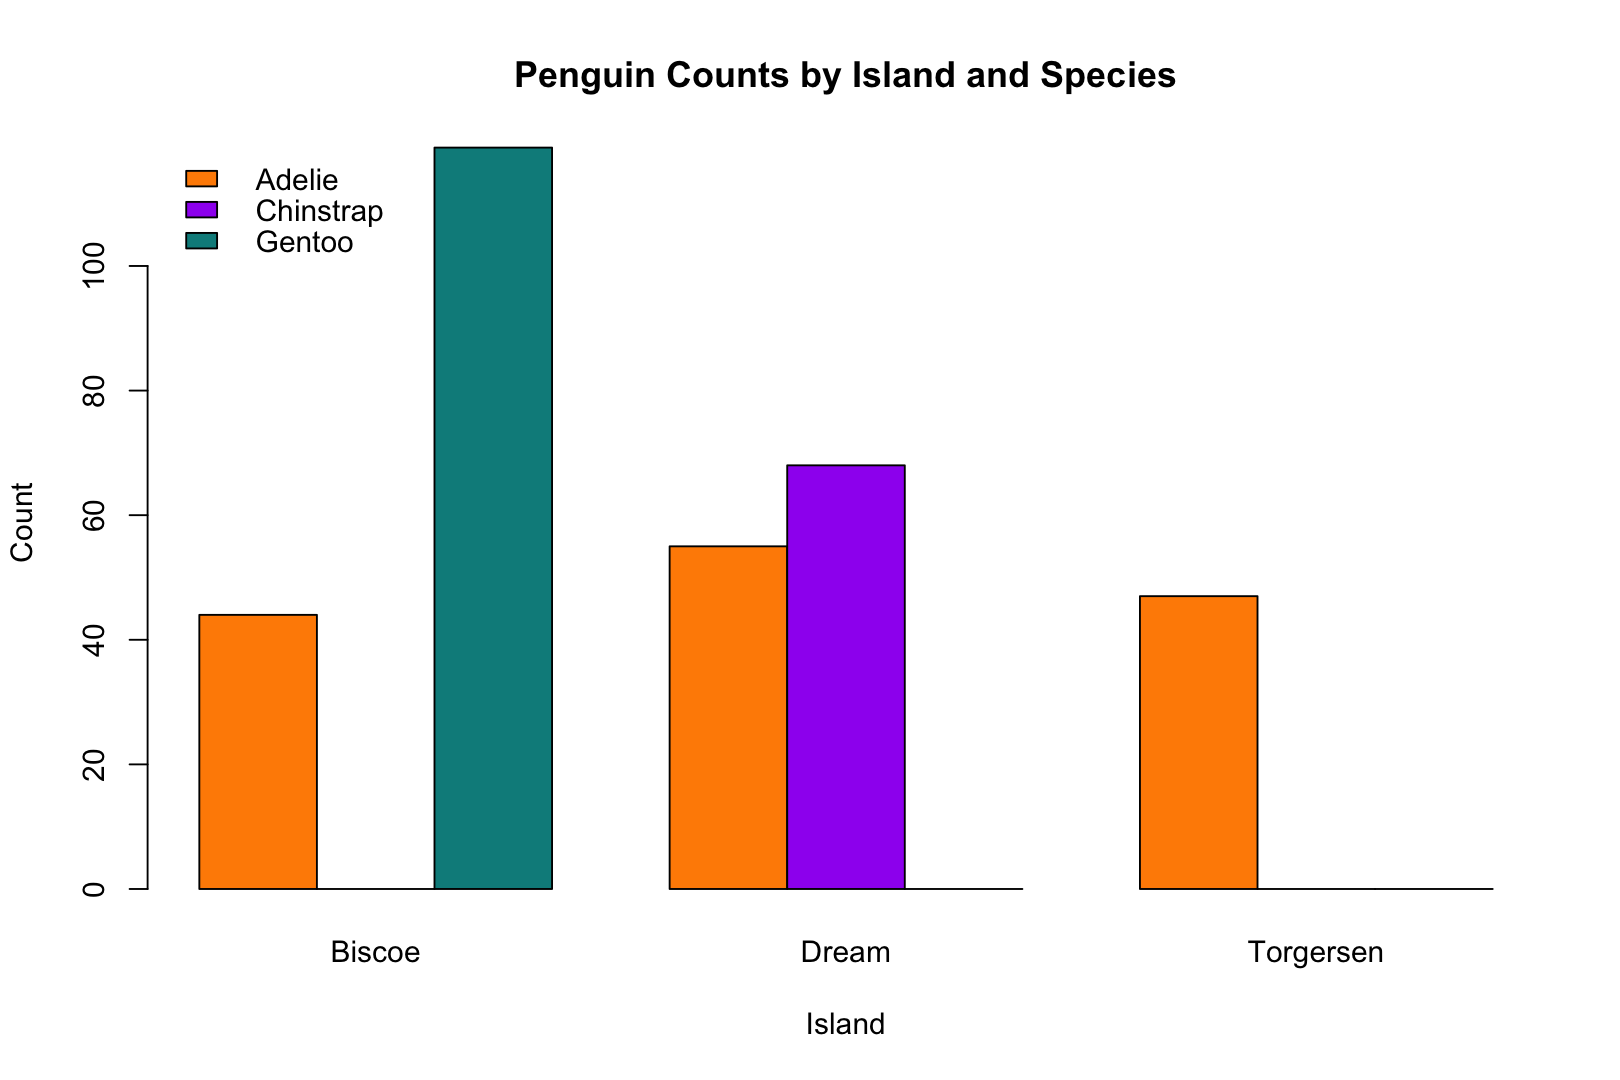

In [5]:
# Count penguins by species and island
count_table <- table(penguins_complete$species, penguins_complete$island)

# Grouped bar plot
barplot(count_table,
        beside  = TRUE,
        col     = species_cols,
        xlab    = "Island",
        ylab    = "Count",
        main    = "Penguin Counts by Island and Species",
        legend  = rownames(count_table),
        args.legend = list(x = "topleft", bty = "n"))

### 5. Density Plots

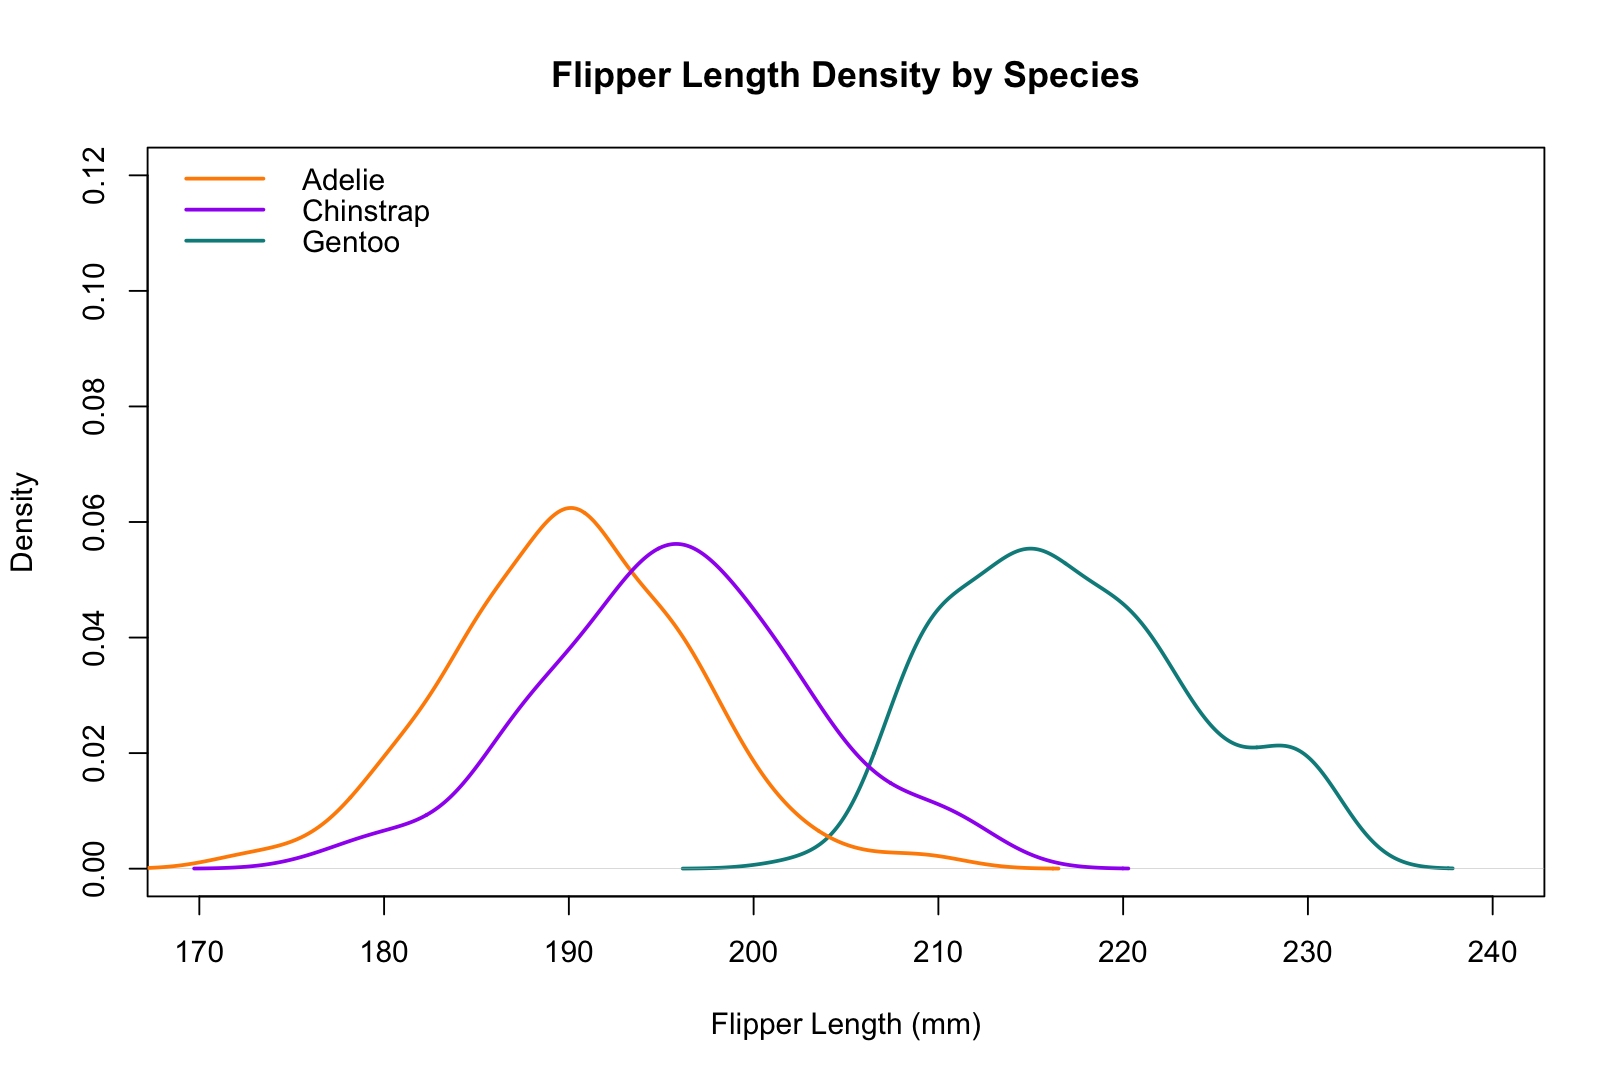

In [6]:
# Overlapping density curves — one per species
adelie    <- penguins_complete$flipper_length_mm[penguins_complete$species == "Adelie"]
chinstrap <- penguins_complete$flipper_length_mm[penguins_complete$species == "Chinstrap"]
gentoo    <- penguins_complete$flipper_length_mm[penguins_complete$species == "Gentoo"]

plot(density(gentoo), col = species_cols["Gentoo"], lwd = 2,
     xlim = c(170, 240), ylim = c(0, 0.12),
     main = "Flipper Length Density by Species",
     xlab = "Flipper Length (mm)", ylab = "Density")

lines(density(adelie),    col = species_cols["Adelie"],    lwd = 2)
lines(density(chinstrap), col = species_cols["Chinstrap"], lwd = 2)

legend("topleft", legend = names(species_cols),
       col = species_cols, lwd = 2, bty = "n")

### 6. Limitations of Base R Graphics

Base R graphics are effective, but they have significant limitations for complex, publication-quality figures:

- Adding a legend requires a separate `legend()` call with manually specified parameters.
- Colour mapping (linking colours to data values) must be done manually.
- Multi-panel figures require `par(mfrow = ...)` and careful margin management.
- Consistent styling across a document requires repetitive code.
- There is no principled grammar — plots are built procedurally, not declaratively.

`ggplot2` was designed to address all of these limitations.

---

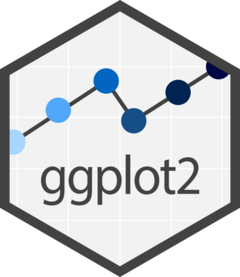

## `ggplot2` — A Grammar of Graphics

`ggplot2` (Wickham, 2010, 2016) implements Wilkinson's (2005) *Grammar of Graphics* — a principled framework that decomposes every plot into the following components:

| Component | Description | ggplot2 function |
|-----------|-------------|-----------------|
| **Data** | The dataset being visualised | `ggplot(data = ...)` |
| **Aesthetics** | Mappings from data to visual properties | `aes(x, y, colour, fill, size, ...)` |
| **Geometries** | The geometric objects that represent data | `geom_*()` |
| **Scales** | How data values map to aesthetic values | `scale_*()` |
| **Facets** | Splitting the plot into subplots | `facet_wrap()`, `facet_grid()` |
| **Statistics** | Statistical transformations of the data | `stat_*()` |
| **Coordinates** | The coordinate system | `coord_*()` |
| **Theme** | Non-data visual elements | `theme()` |

Three rules govern every `ggplot2` plot:
1. **Plots are built by accumulation**: start with a base and add layers.
2. **Aesthetics are data-driven or constant — never both**: if it varies with data, it belongs inside `aes()`; if it is fixed, it belongs outside.
3. **Grouping is identity**: it tells `ggplot2` which observations belong together across layers.

**References:**
- Wickham, H. (2016). *ggplot2: Elegant Graphics for Data Analysis* (2nd ed.). Springer. https://ggplot2-book.org
- Wilkinson, L. (2005). *The Grammar of Graphics* (2nd ed.). Springer.

---
## Building a Plot — One Layer at a Time

The most important pedagogical principle in learning `ggplot2` is that every layer you add incrementally improves the figure. A figure is never finished in one call — it is refined through successive additions.

Let us build a complete figure from scratch, adding exactly **one element per step**.

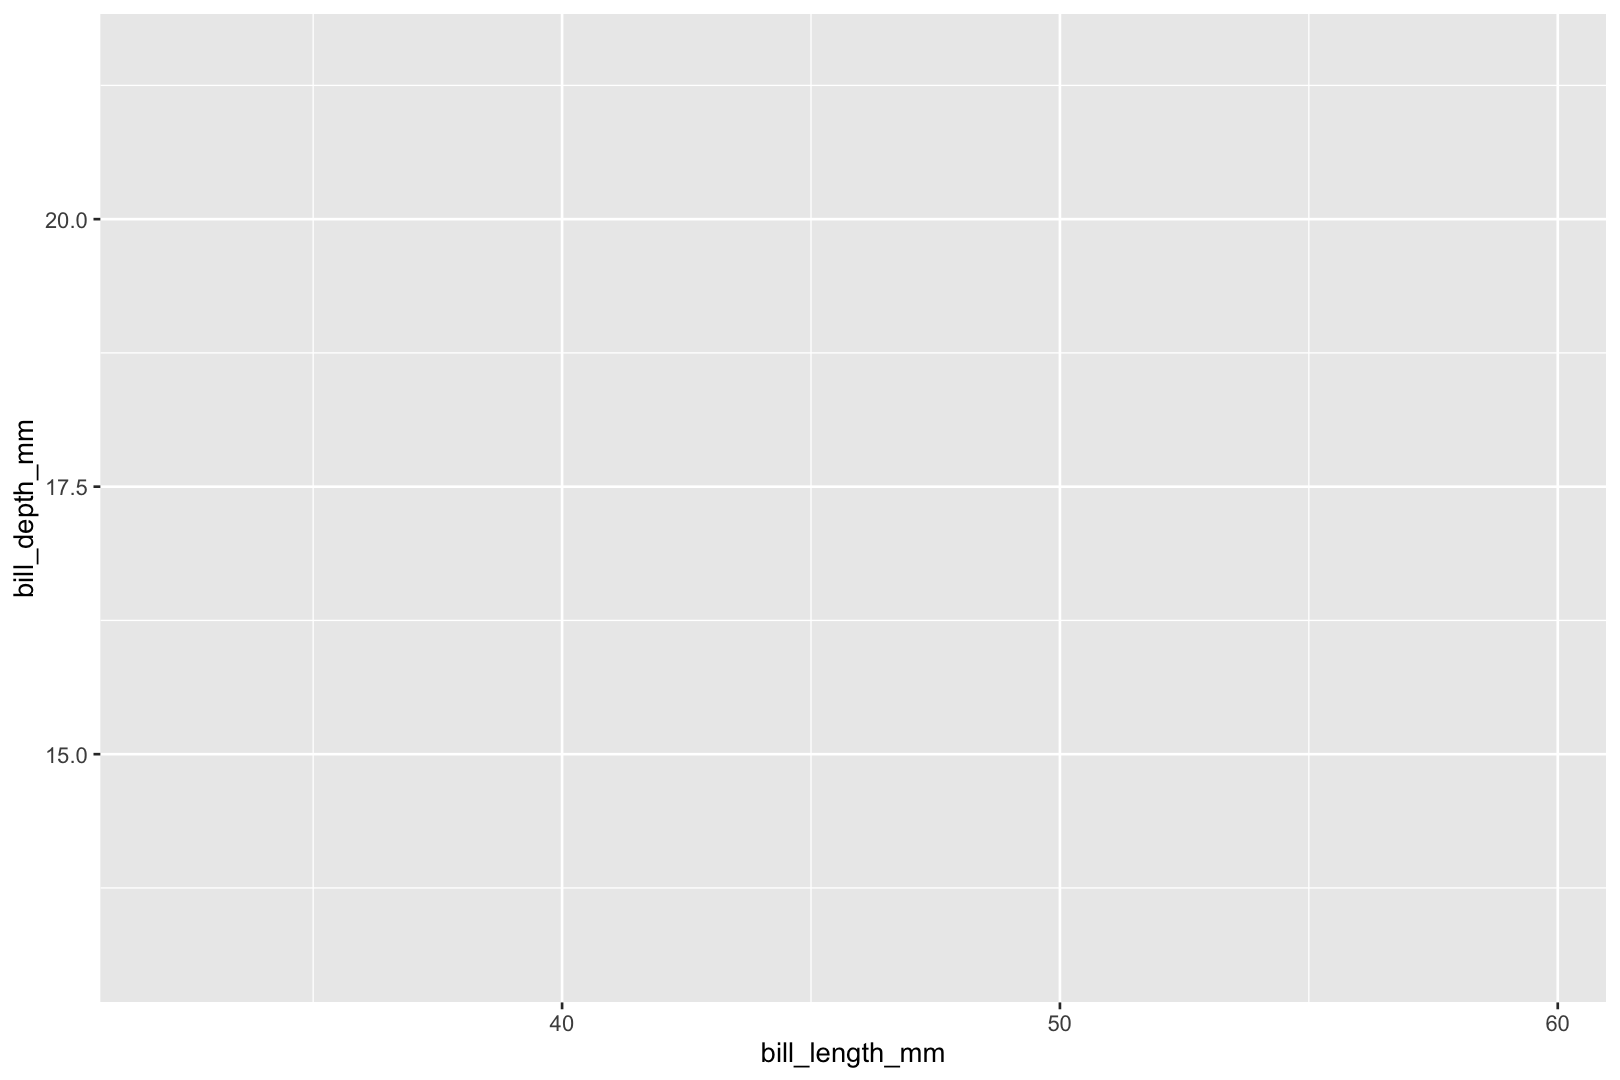

In [7]:
# Step 1: An empty canvas
# ggplot() initialises the plot — it defines the data and global aesthetics
# but produces nothing visible yet.

ggplot(data    = penguins_complete,
       mapping = aes(x = bill_length_mm,
                     y = bill_depth_mm))

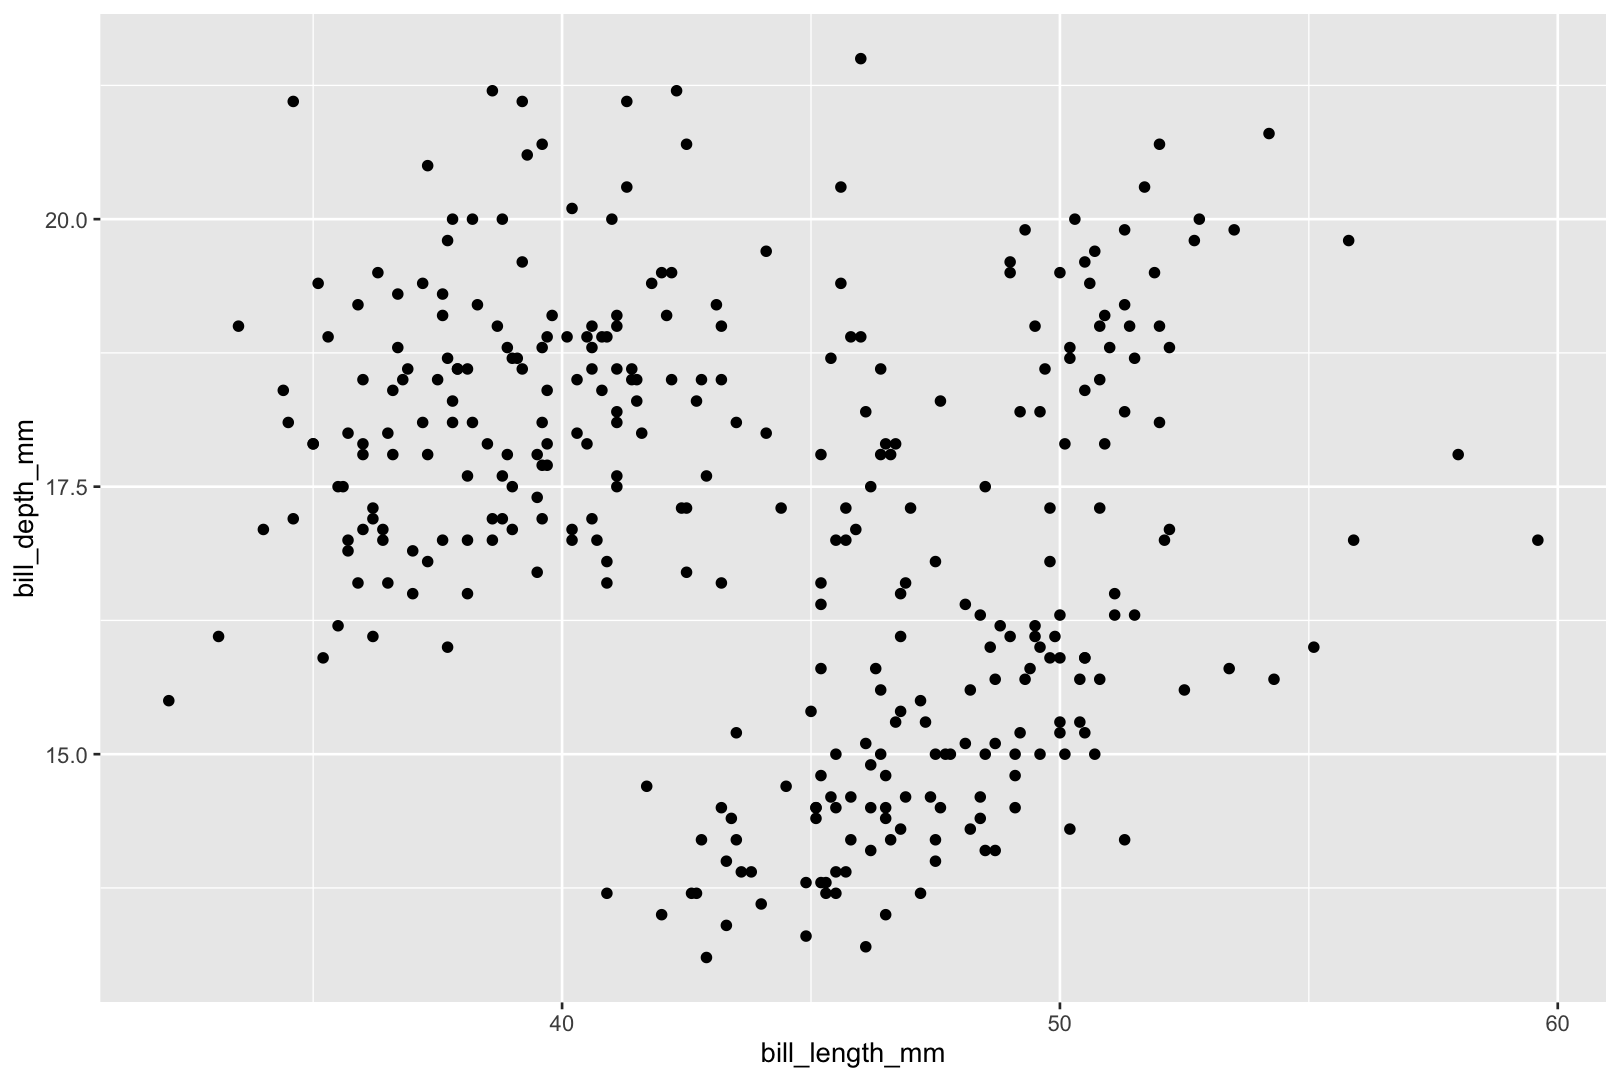

In [8]:
# Step 2: Add a geometry (+ geom_point)
# geom_point() adds a scatter plot layer
# Note: all layers are connected with the + operator

ggplot(data    = penguins_complete,
       mapping = aes(x = bill_length_mm,
                     y = bill_depth_mm)) +
  geom_point()

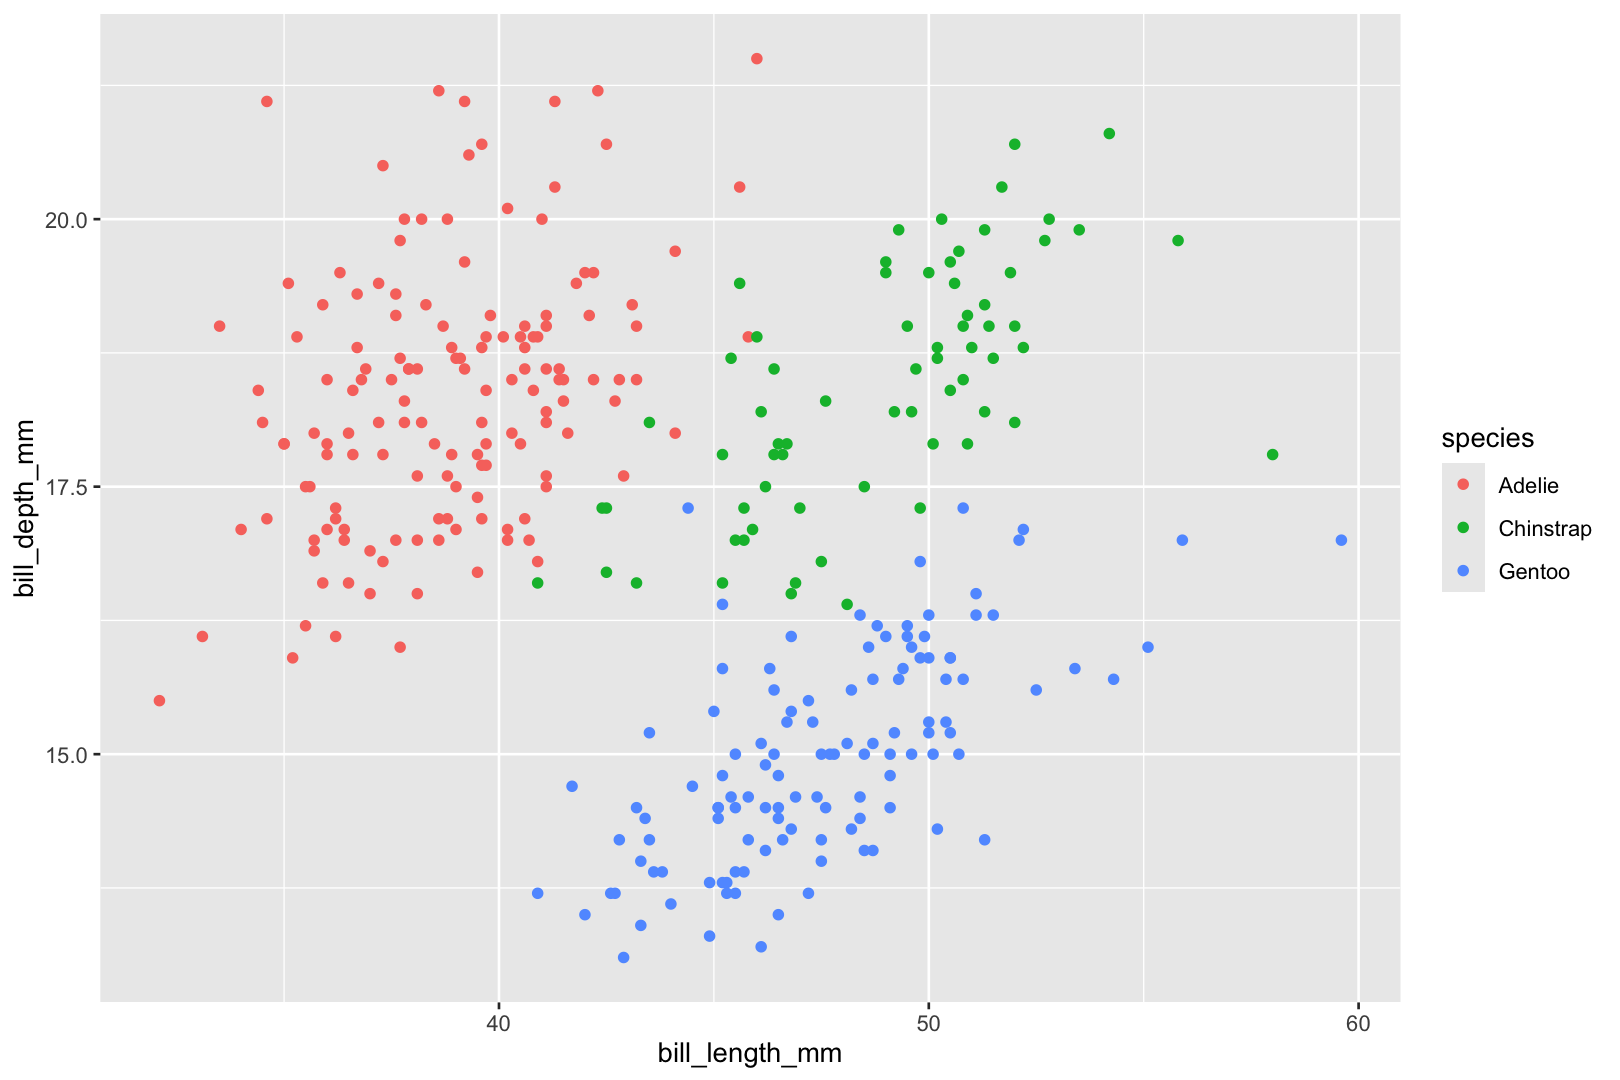

In [9]:
# Step 3: Map colour to species (+ colour = species inside aes)
# Moving colour INTO aes() links it to data — ggplot2 assigns colours automatically
# and creates a legend without any additional code

ggplot(data    = penguins_complete,
       mapping = aes(x      = bill_length_mm,
                     y      = bill_depth_mm,
                     colour = species)) +
  geom_point()

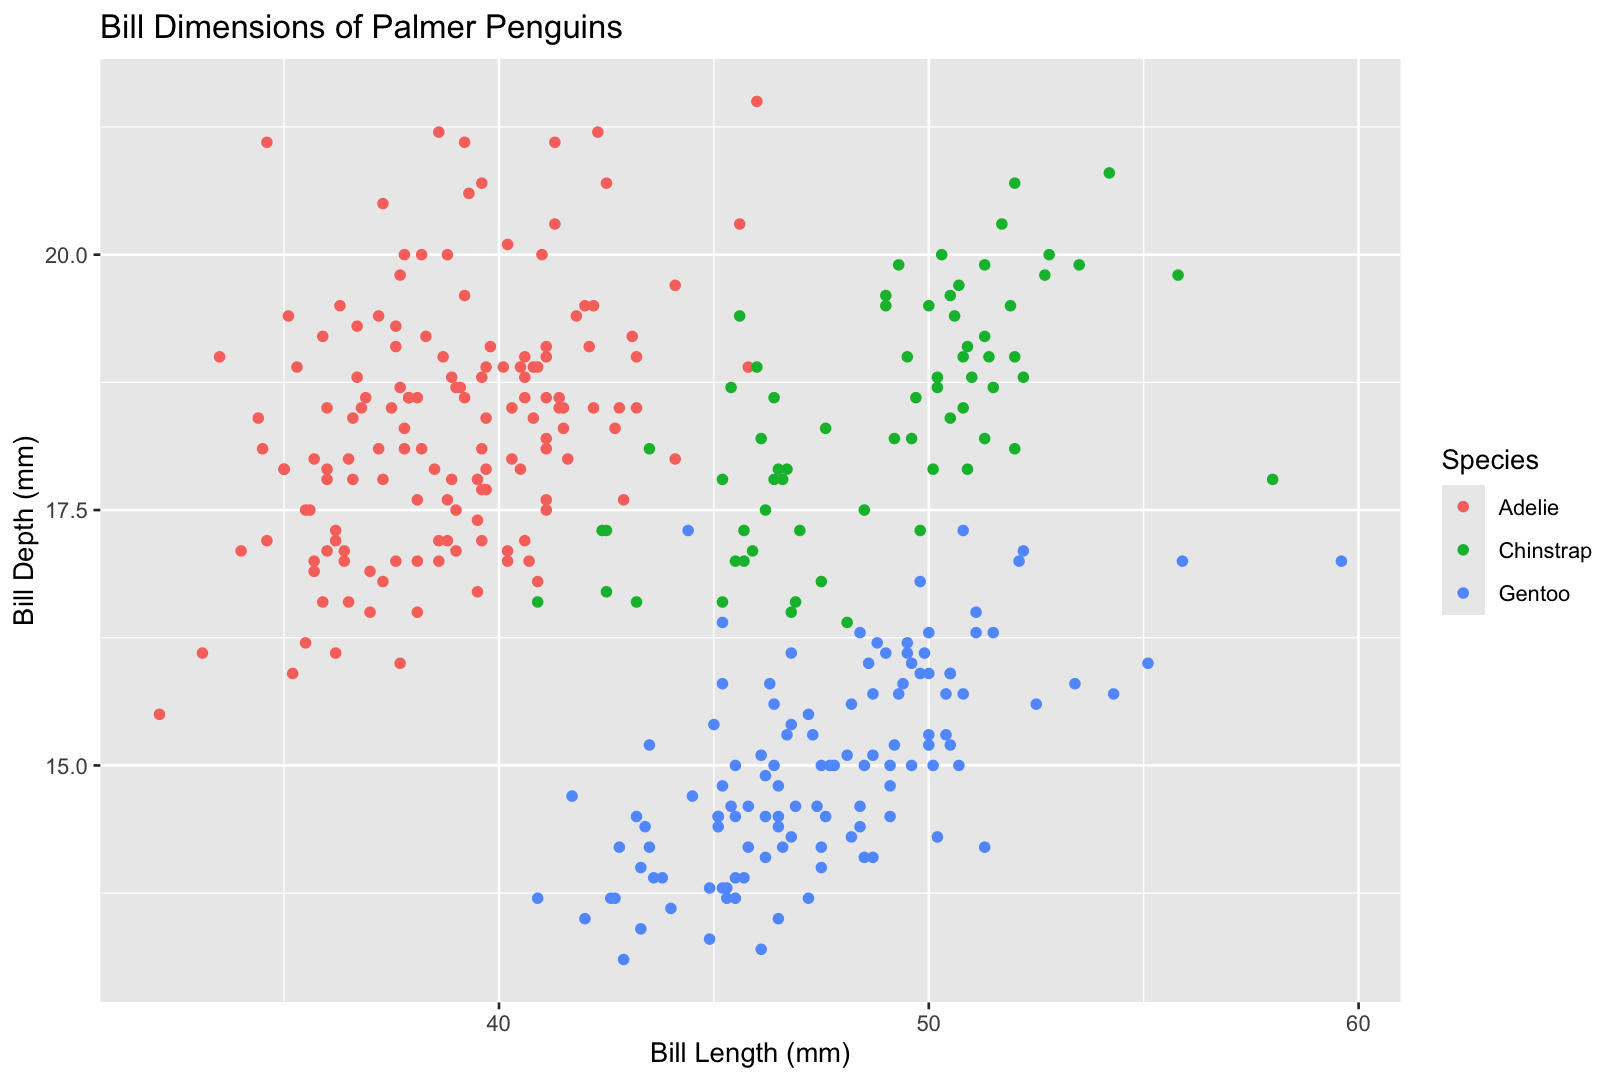

In [10]:
# Step 4: Add axis labels and a title (+ labs)
# labs() modifies all text labels — axes, legend, title, subtitle, caption

ggplot(data    = penguins_complete,
       mapping = aes(x      = bill_length_mm,
                     y      = bill_depth_mm,
                     colour = species)) +
  geom_point() +
  labs(x      = "Bill Length (mm)",
       y      = "Bill Depth (mm)",
       colour = "Species",
       title  = "Bill Dimensions of Palmer Penguins")

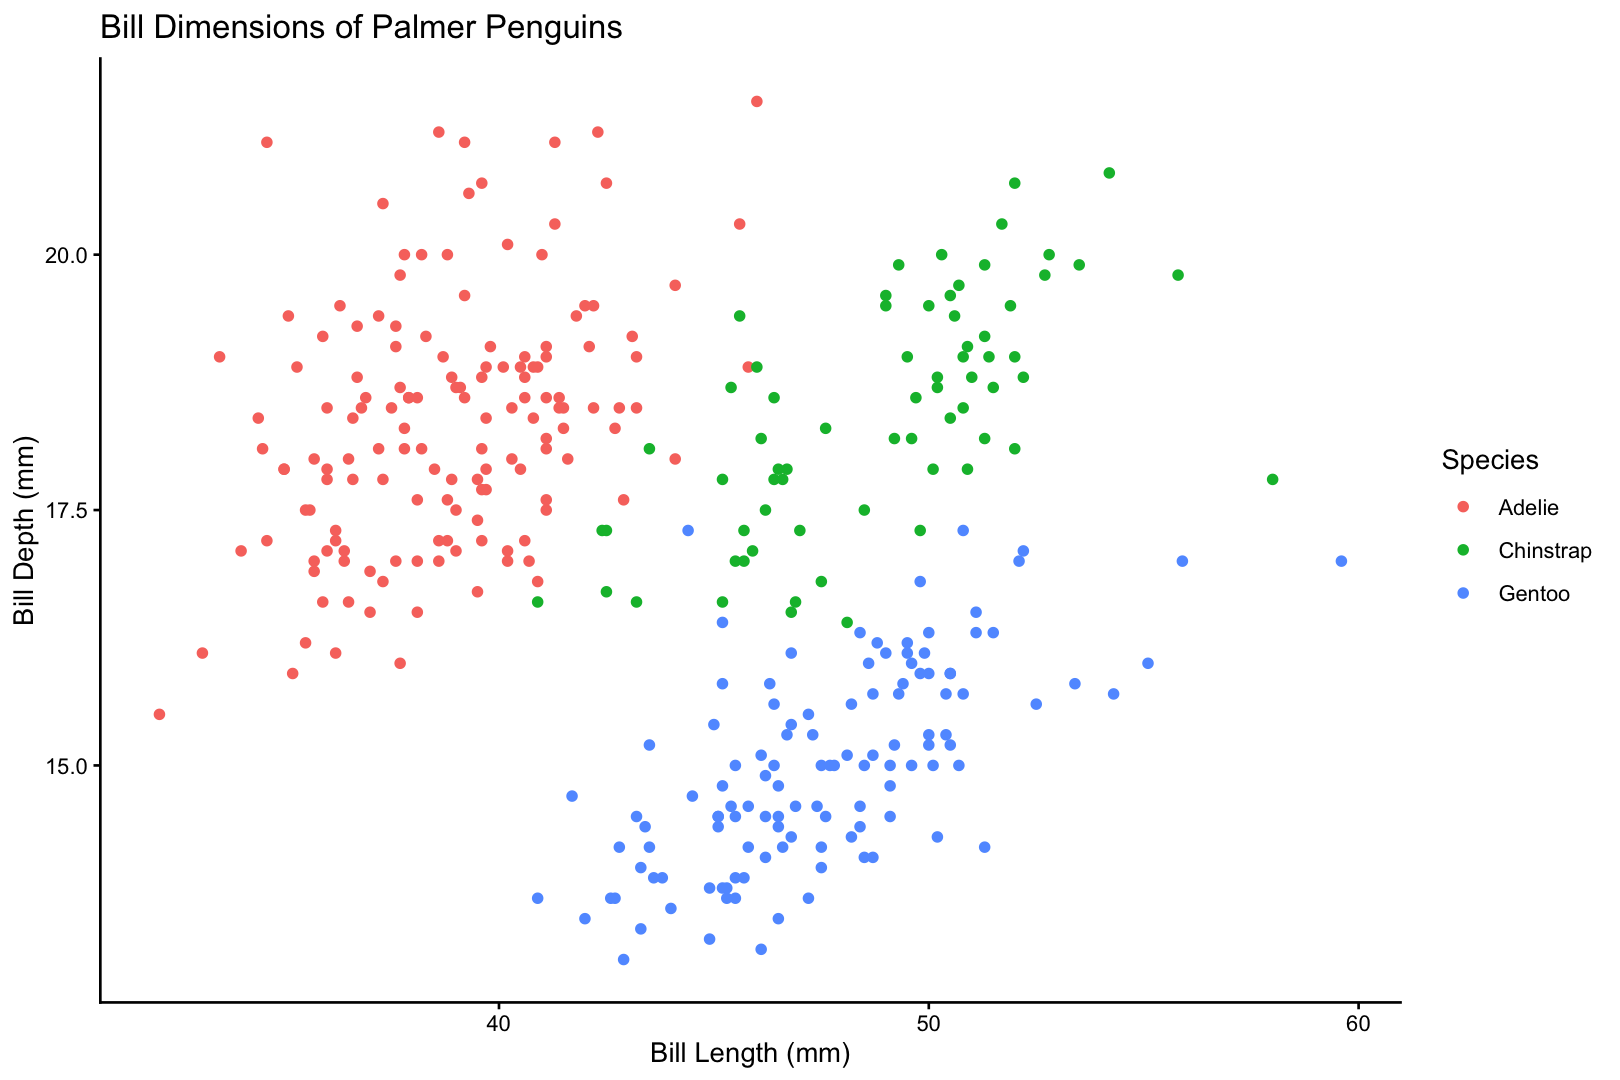

In [11]:
# Step 5: Apply a clean theme (+ theme_classic)
# theme_classic() removes the grey background and uses a clean axis-line style
# Other options: theme_bw(), theme_minimal(), theme_light()

ggplot(data    = penguins_complete,
       mapping = aes(x      = bill_length_mm,
                     y      = bill_depth_mm,
                     colour = species)) +
  geom_point() +
  labs(x      = "Bill Length (mm)",
       y      = "Bill Depth (mm)",
       colour = "Species",
       title  = "Bill Dimensions of Palmer Penguins") +
  theme_classic()

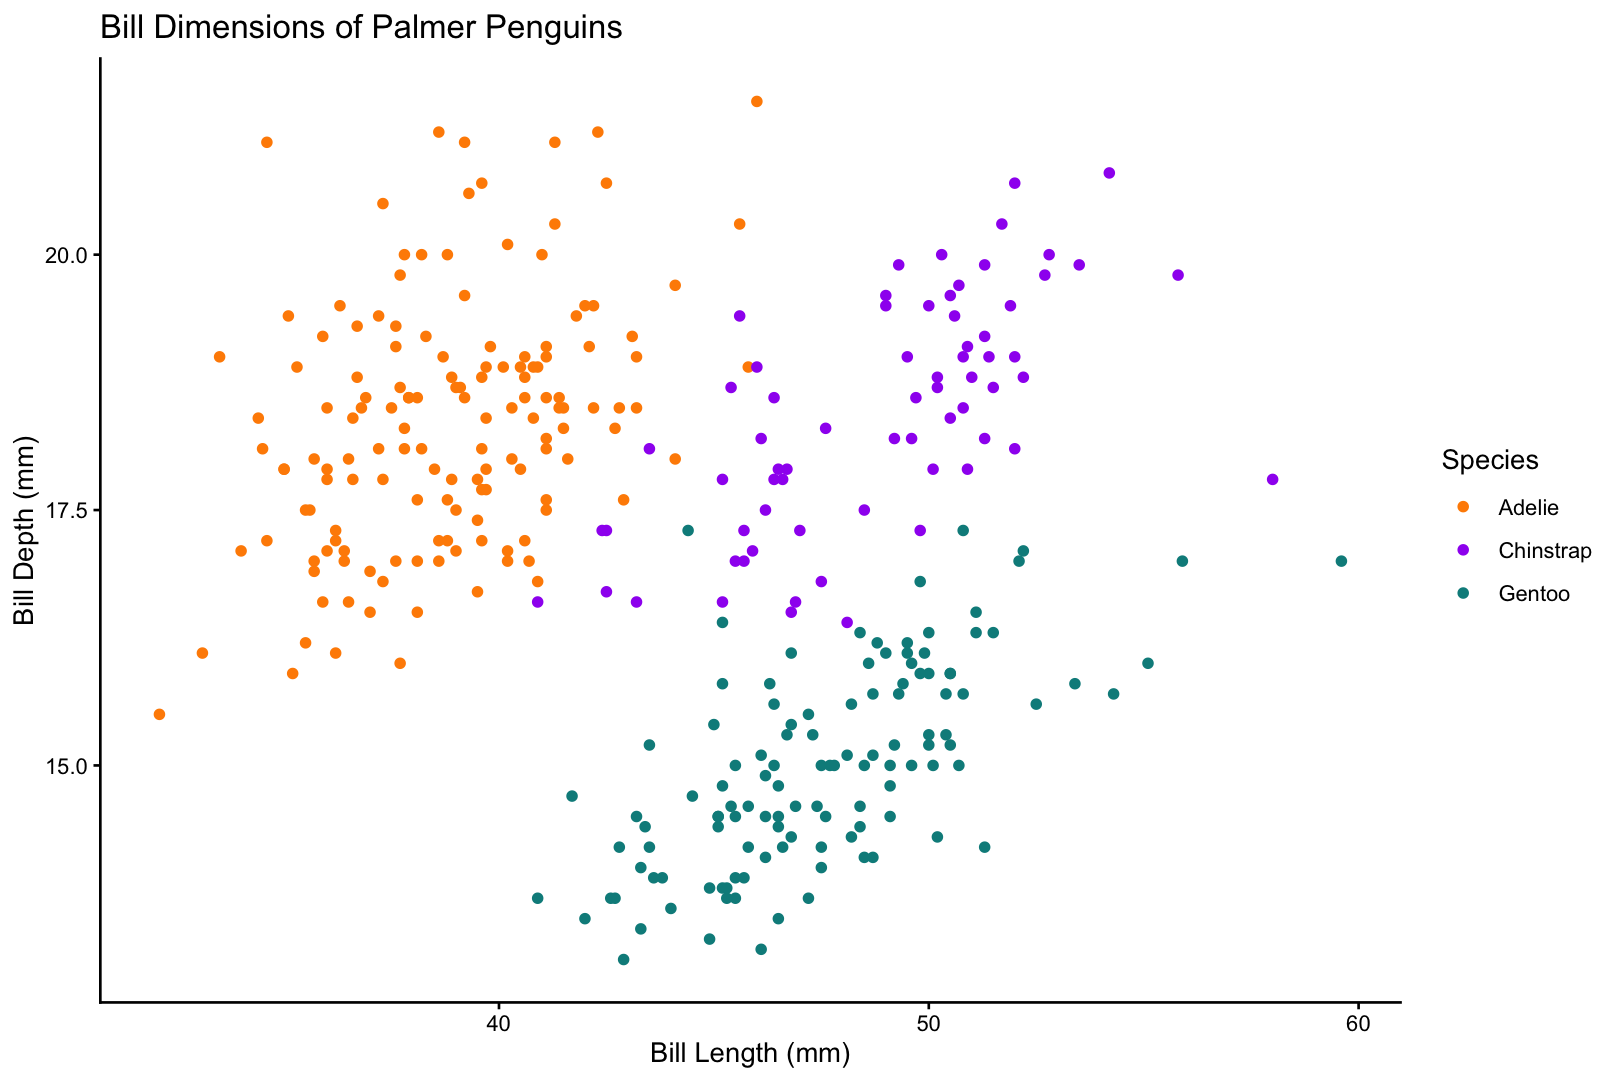

In [12]:
# Step 6: Use ecologically meaningful colours (+ scale_colour_manual)
# Replace the default palette with the published penguin colour scheme

ggplot(data    = penguins_complete,
       mapping = aes(x      = bill_length_mm,
                     y      = bill_depth_mm,
                     colour = species)) +
  geom_point() +
  scale_colour_manual(values = c("darkorange", "purple", "cyan4")) +
  labs(x      = "Bill Length (mm)",
       y      = "Bill Depth (mm)",
       colour = "Species",
       title  = "Bill Dimensions of Palmer Penguins") +
  theme_classic()

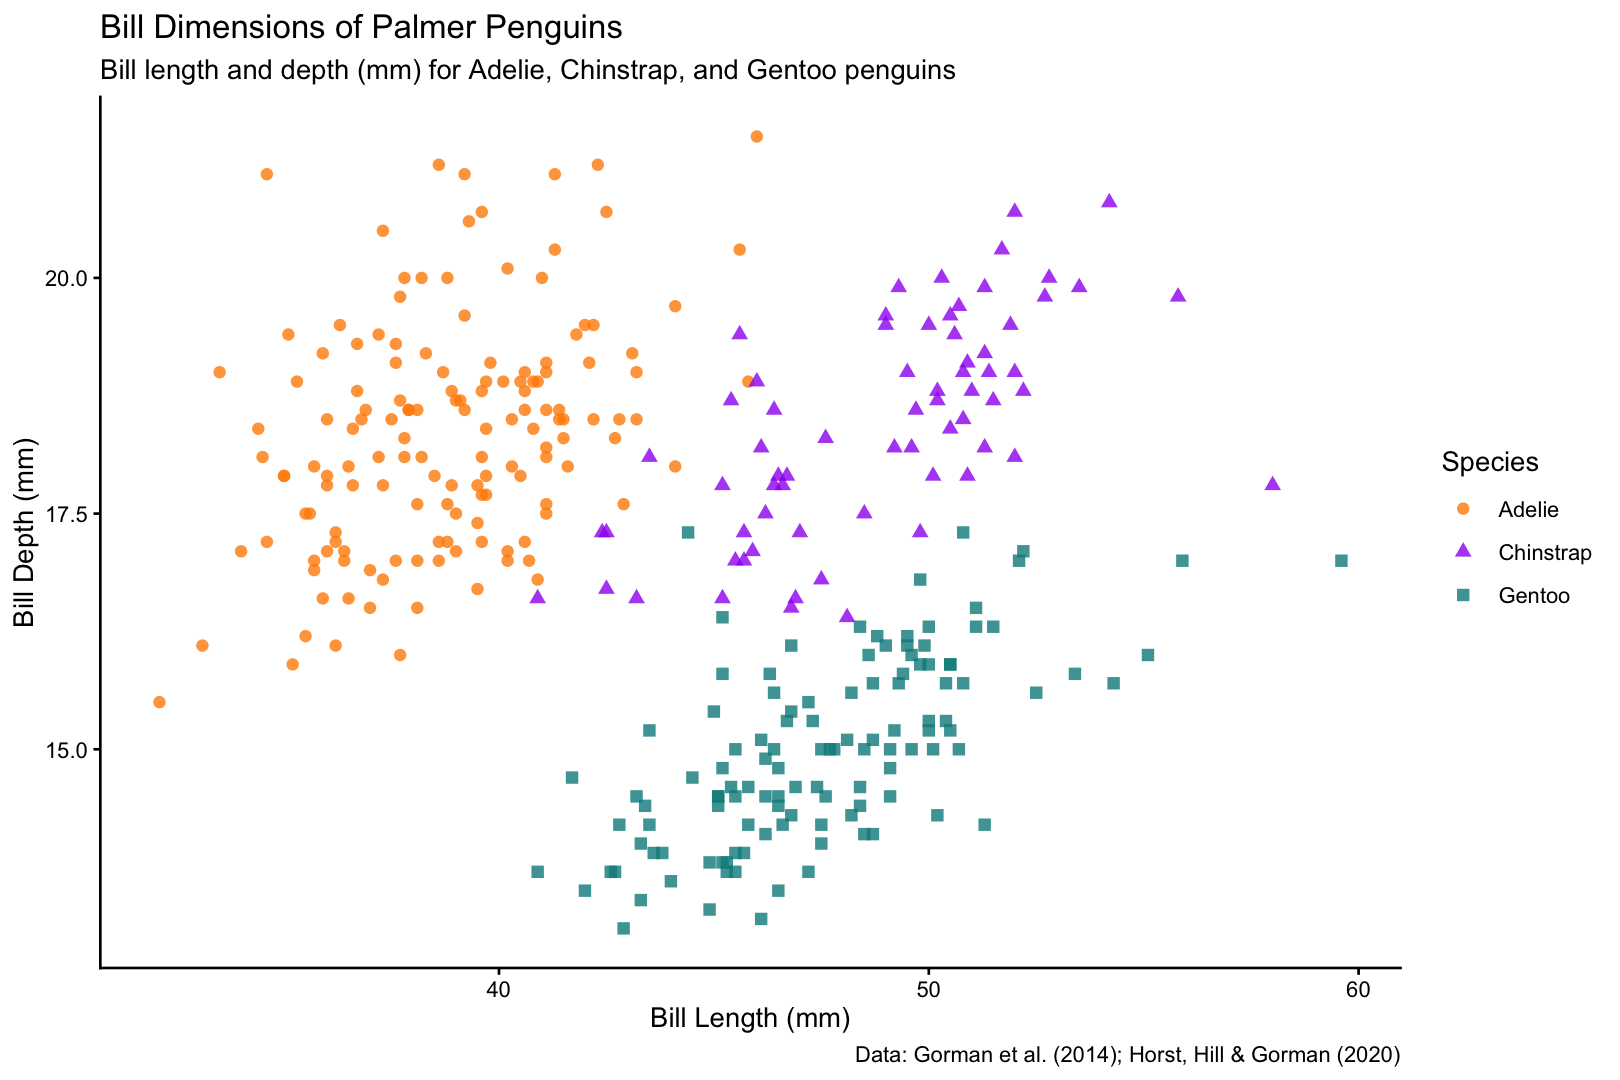

In [13]:
# Step 7: Add shape mapping for accessibility (+ shape = species inside aes)
# Using both colour and shape improves legibility in greyscale printing
# and for readers with colour vision deficiency

ggplot(data    = penguins_complete,
       mapping = aes(x      = bill_length_mm,
                     y      = bill_depth_mm,
                     colour = species,
                     shape  = species)) +
  geom_point(size = 2, alpha = 0.8) +
  scale_colour_manual(values = c("darkorange", "purple", "cyan4")) +
  labs(x      = "Bill Length (mm)",
       y      = "Bill Depth (mm)",
       colour = "Species",
       shape  = "Species",
       title  = "Bill Dimensions of Palmer Penguins",
       subtitle = "Bill length and depth (mm) for Adelie, Chinstrap, and Gentoo penguins",
       caption = "Data: Gorman et al. (2014); Horst, Hill & Gorman (2020)") +
  theme_classic()

`geom_smooth()` using formula = 'y ~ x'


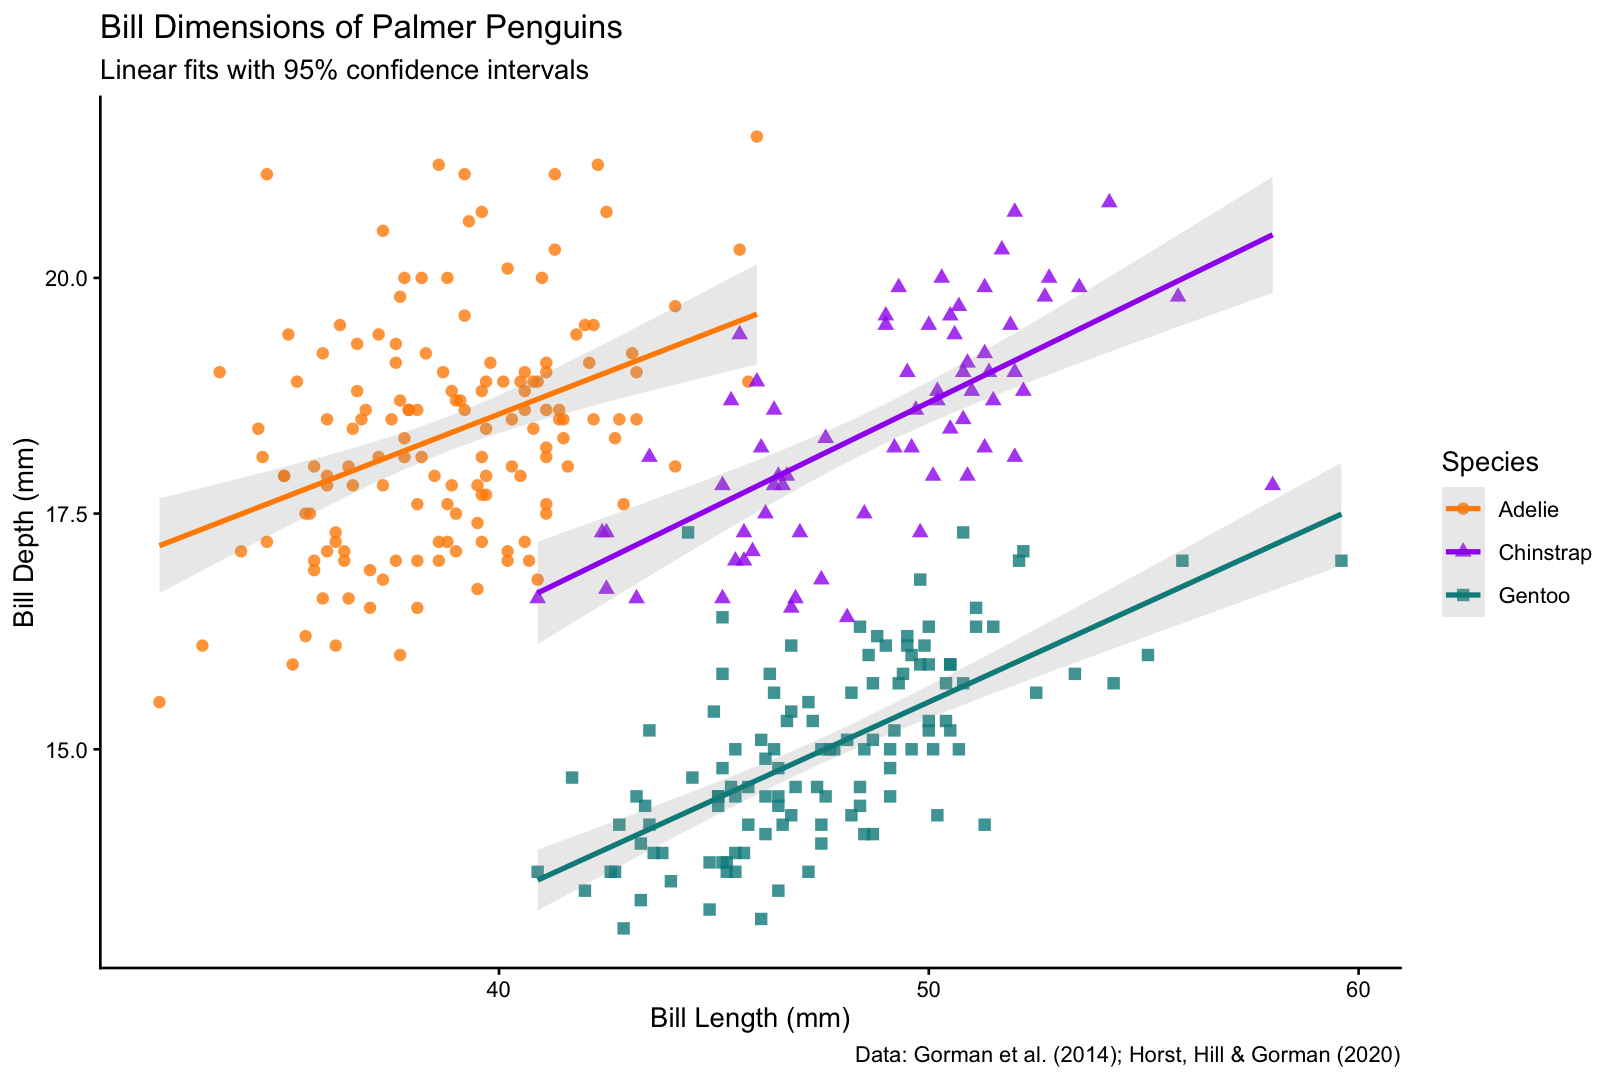

In [14]:
# Step 8: Add a linear trend line per species (+ geom_smooth)
# geom_smooth inherits the colour and shape aesthetics from ggplot()

ggplot(data    = penguins_complete,
       mapping = aes(x      = bill_length_mm,
                     y      = bill_depth_mm,
                     colour = species,
                     shape  = species)) +
  geom_point(size = 2, alpha = 0.8) +
  geom_smooth(method = "lm", se = TRUE, alpha = 0.2) +
  scale_colour_manual(values = c("darkorange", "purple", "cyan4")) +
  labs(x      = "Bill Length (mm)",
       y      = "Bill Depth (mm)",
       colour = "Species",
       shape  = "Species",
       title  = "Bill Dimensions of Palmer Penguins",
       subtitle = "Linear fits with 95% confidence intervals",
       caption = "Data: Gorman et al. (2014); Horst, Hill & Gorman (2020)") +
  theme_classic()

### What we have shown

Each `+` line added exactly **one feature**:
1. `ggplot()` — canvas
2. `geom_point()` — data points
3. `colour = species` inside `aes()` — colour mapping
4. `labs()` — axis and title labels
5. `theme_classic()` — clean styling
6. `scale_colour_manual()` — custom colours
7. `shape = species` + `alpha` — shape mapping
8. `geom_smooth()` — trend lines

This is the grammar of graphics in action: **layers stack to compose complex figures from simple parts**.

---

## Common Geometry Types

`ggplot2` provides over 40 `geom_*` functions. Here are the most common in ecological research.

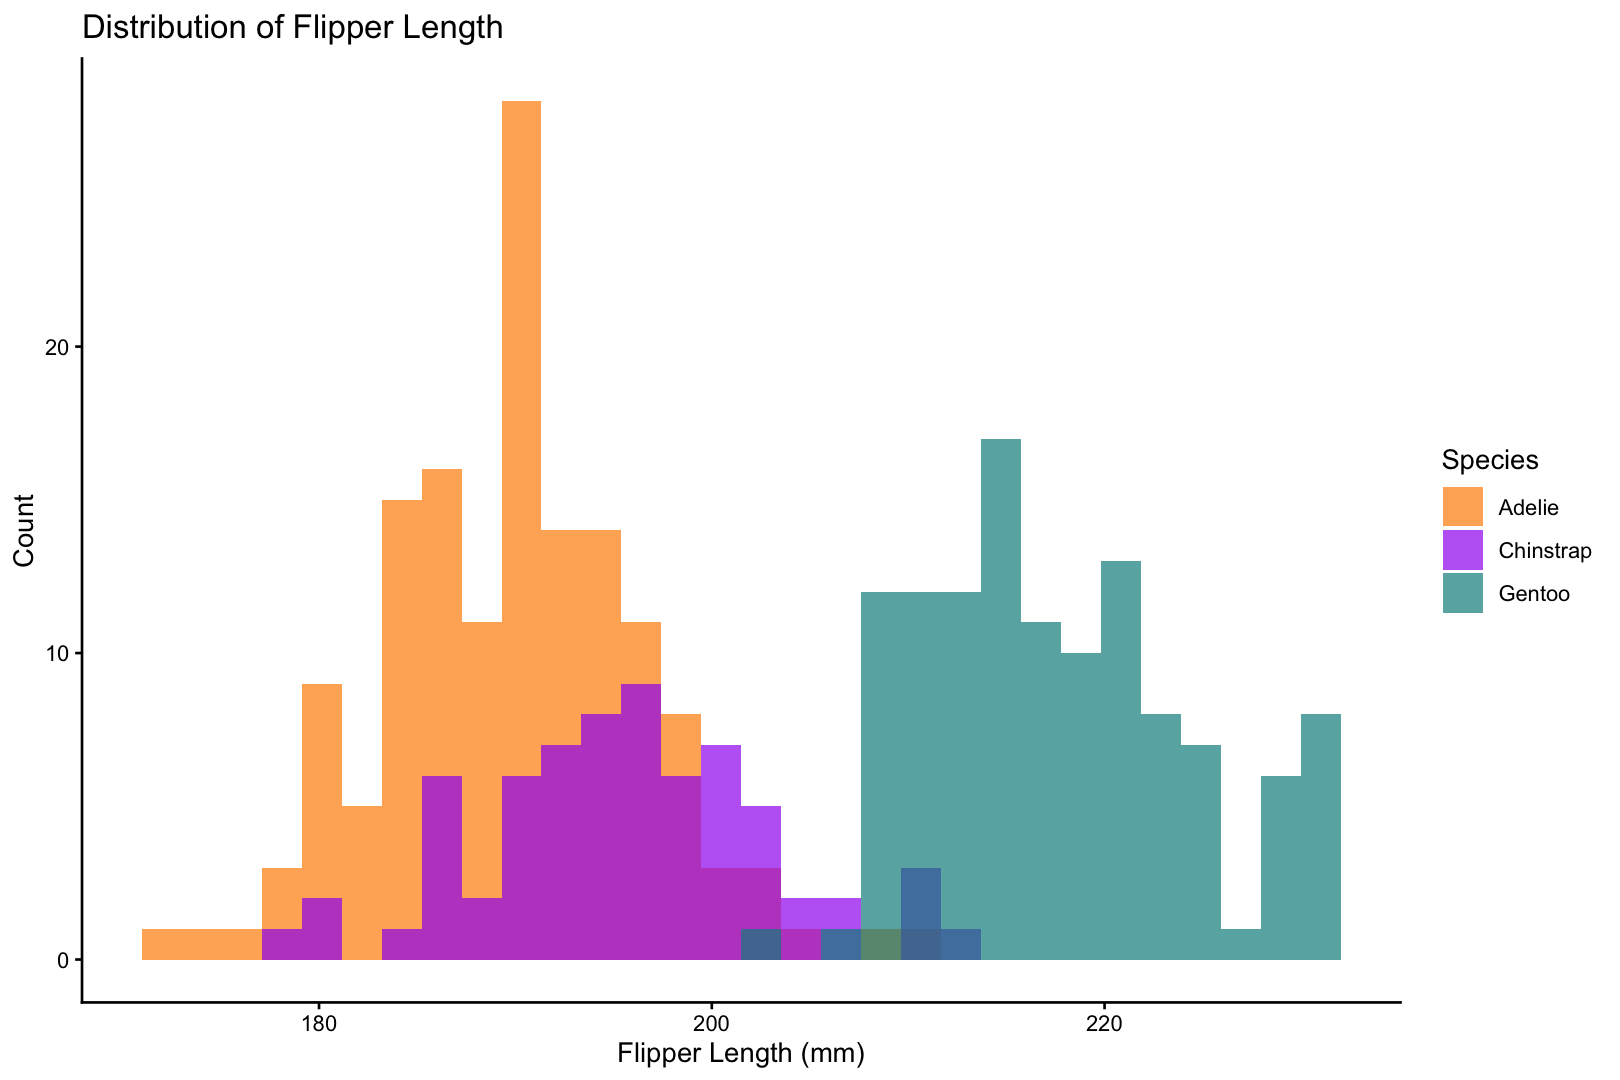

In [15]:
# Histogram
ggplot(penguins_complete, aes(x = flipper_length_mm, fill = species)) +
  geom_histogram(bins = 30, alpha = 0.7, position = "identity") +
  scale_fill_manual(values = c("darkorange", "purple", "cyan4")) +
  labs(x = "Flipper Length (mm)", y = "Count", fill = "Species",
       title = "Distribution of Flipper Length") +
  theme_classic()

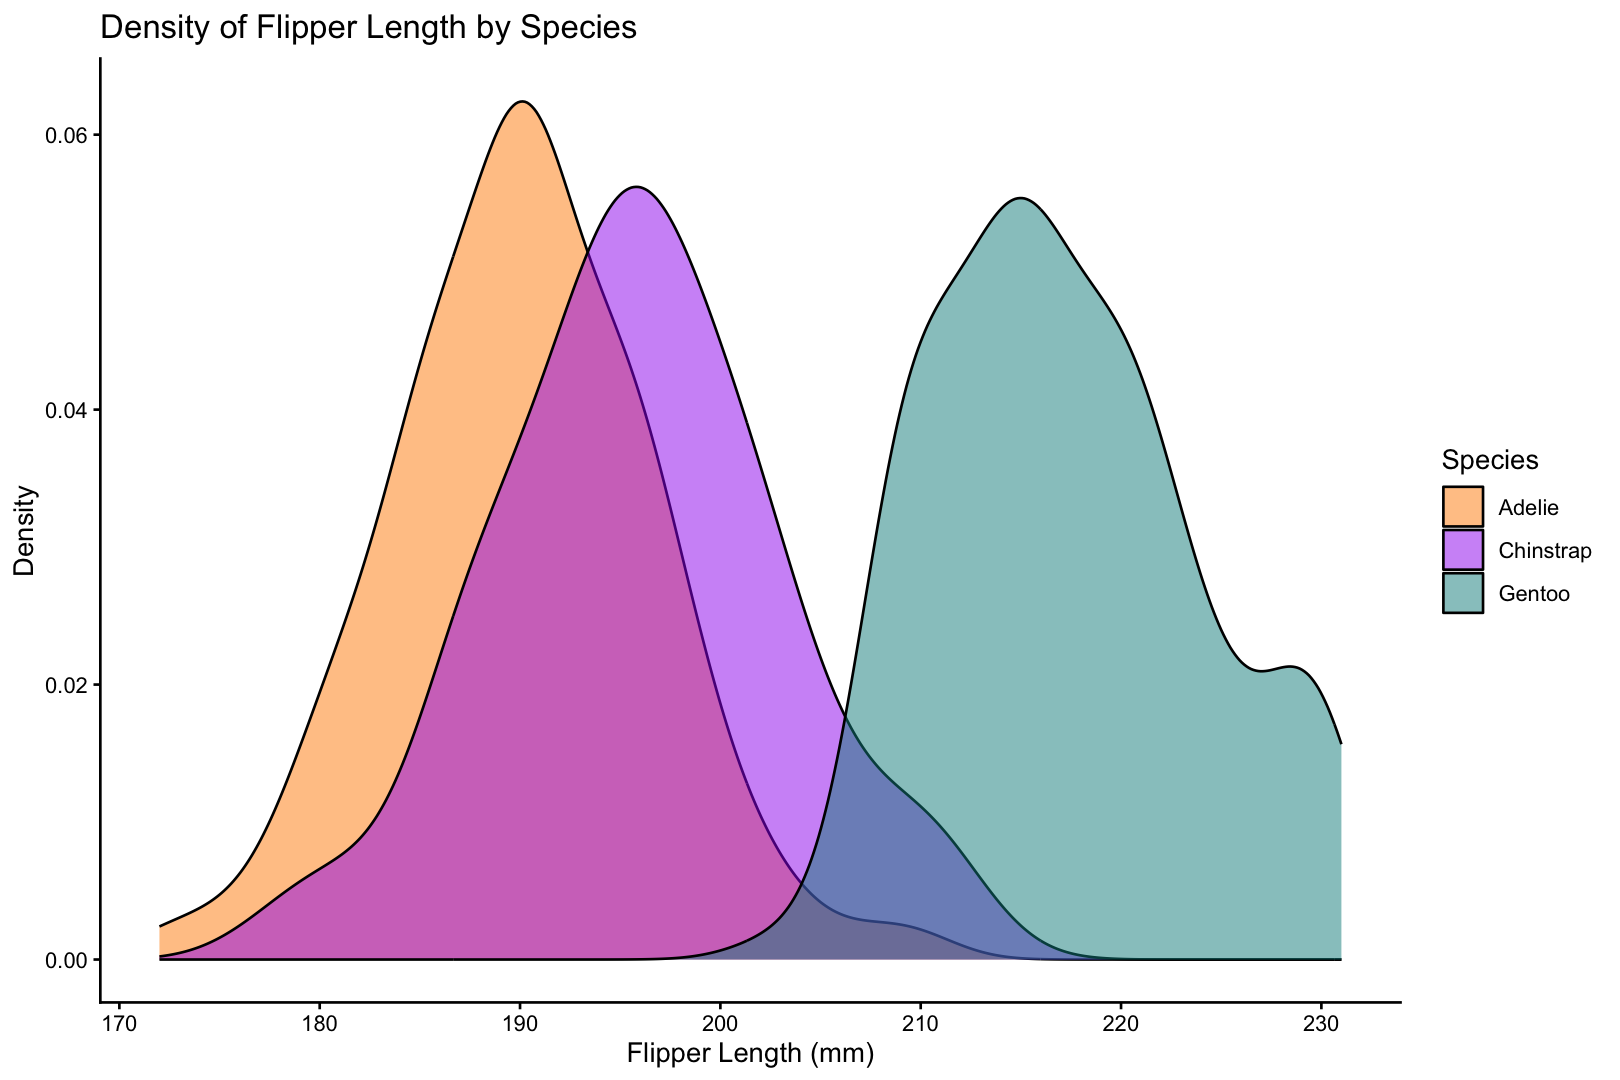

In [16]:
# Density plot
ggplot(penguins_complete, aes(x = flipper_length_mm, fill = species)) +
  geom_density(alpha = 0.5) +
  scale_fill_manual(values = c("darkorange", "purple", "cyan4")) +
  labs(x = "Flipper Length (mm)", y = "Density", fill = "Species",
       title = "Density of Flipper Length by Species") +
  theme_classic()

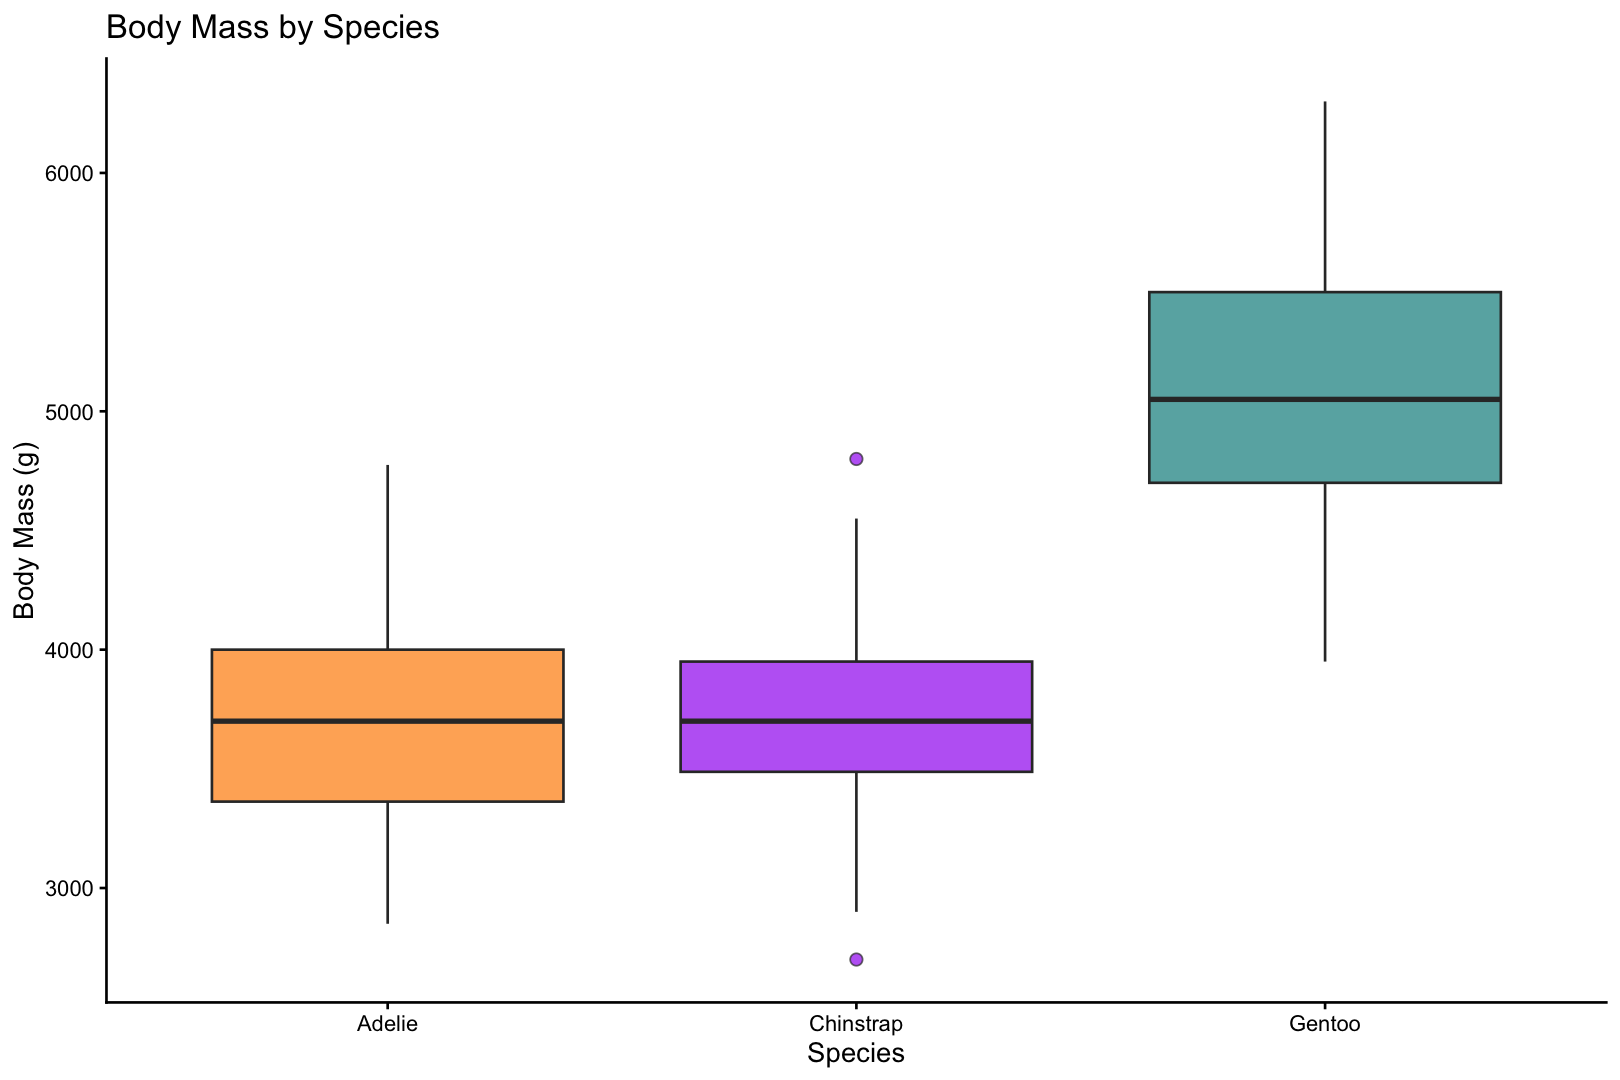

In [17]:
# Box plot
ggplot(penguins_complete, aes(x = species, y = body_mass_g, fill = species)) +
  geom_boxplot(alpha = 0.7, outlier.shape = 21, outlier.size = 2) +
  scale_fill_manual(values = c("darkorange", "purple", "cyan4")) +
  labs(x = "Species", y = "Body Mass (g)", fill = "Species",
       title = "Body Mass by Species") +
  theme_classic() +
  theme(legend.position = "none")   # legend redundant when x = group

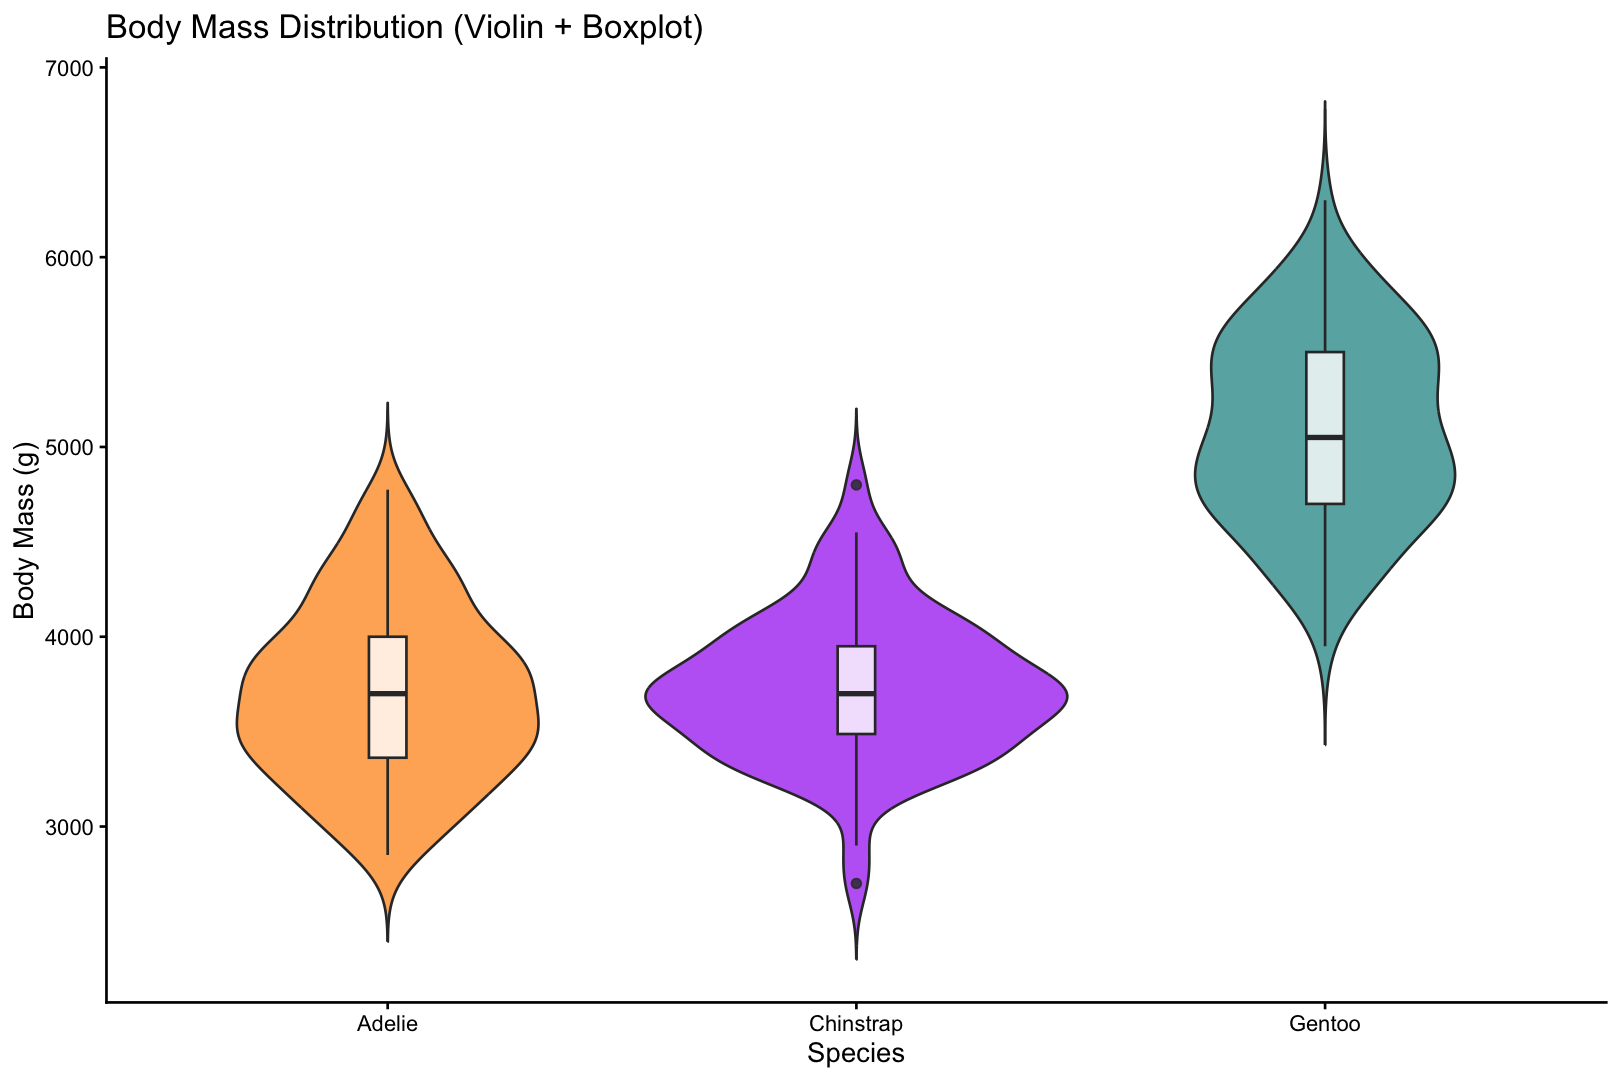

In [18]:
# Violin plot — shows the full distribution shape
ggplot(penguins_complete, aes(x = species, y = body_mass_g, fill = species)) +
  geom_violin(alpha = 0.7, trim = FALSE) +
  geom_boxplot(width = 0.08, fill = "white", alpha = 0.8) +  # embedded boxplot
  scale_fill_manual(values = c("darkorange", "purple", "cyan4")) +
  labs(x = "Species", y = "Body Mass (g)", fill = "Species",
       title = "Body Mass Distribution (Violin + Boxplot)") +
  theme_classic() +
  theme(legend.position = "none")

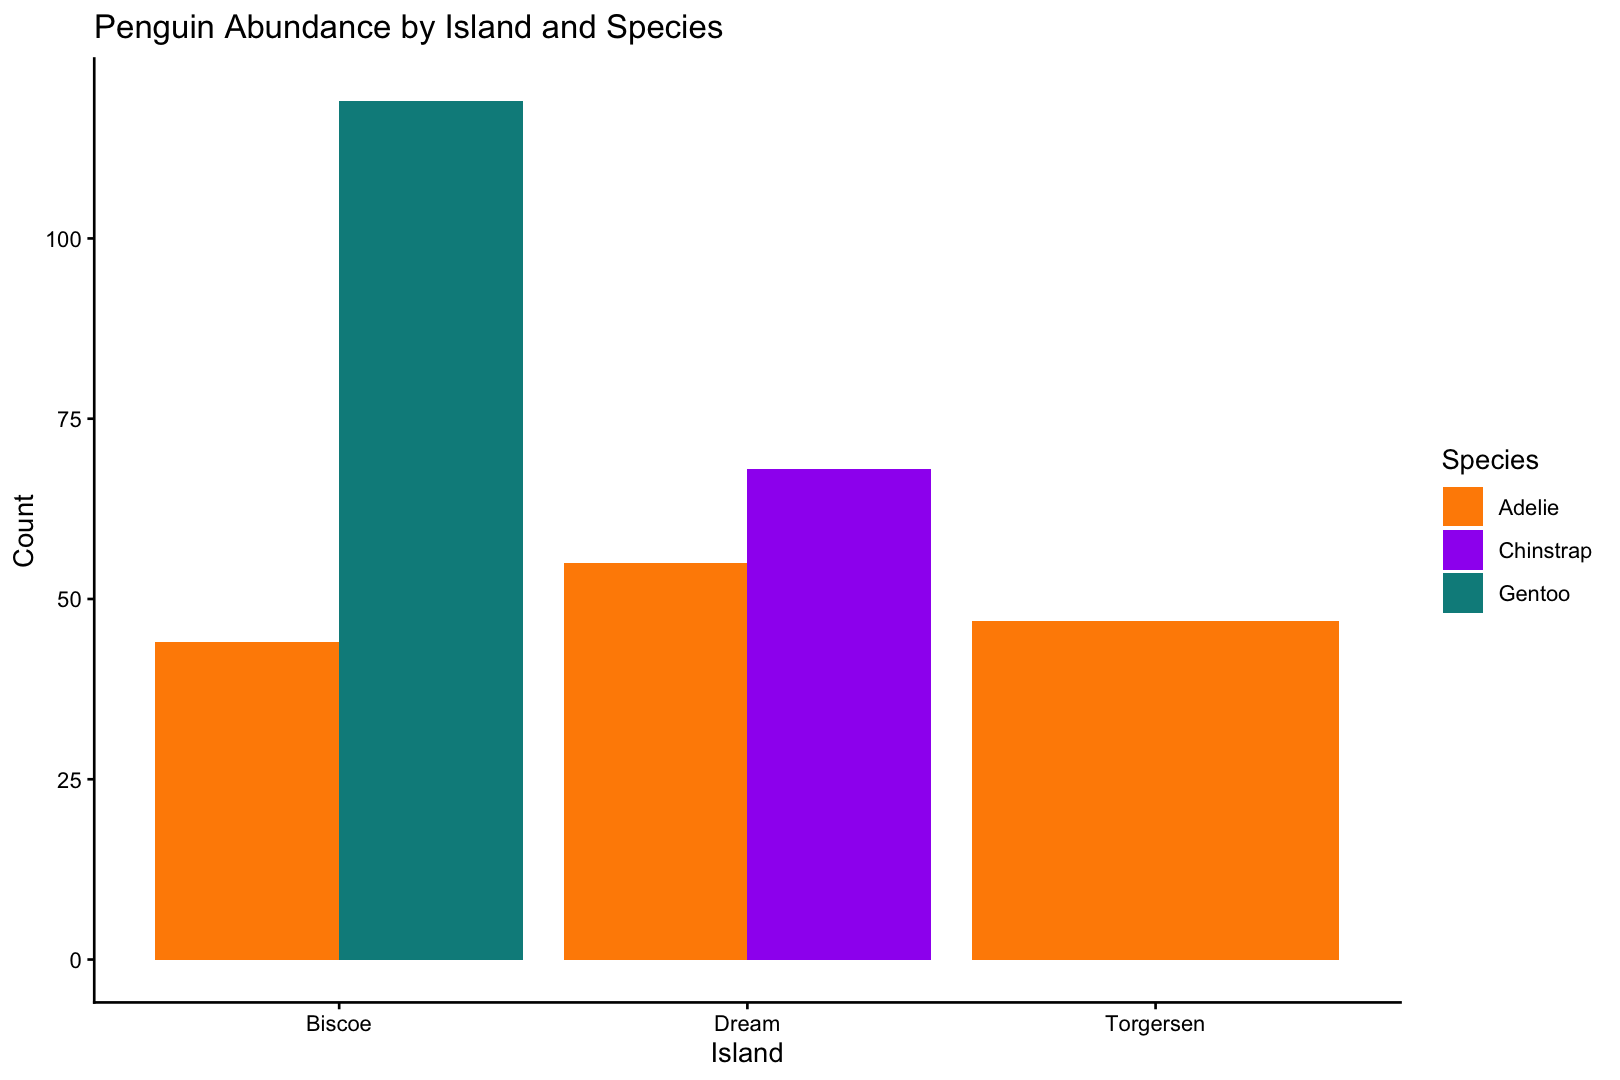

In [19]:
# Bar chart — summarised counts with geom_bar
ggplot(penguins_complete, aes(x = island, fill = species)) +
  geom_bar(position = "dodge") +
  scale_fill_manual(values = c("darkorange", "purple", "cyan4")) +
  labs(x = "Island", y = "Count", fill = "Species",
       title = "Penguin Abundance by Island and Species") +
  theme_classic()

---
## Faceting — Small Multiples

**Faceting** splits a plot into a grid of sub-plots, one per level of a variable. It is one of the most powerful tools in ggplot2 for revealing structure in ecological data.

> *"Comparisons within small multiples are better than comparisons between separate charts."*
> — Tufte (1983)

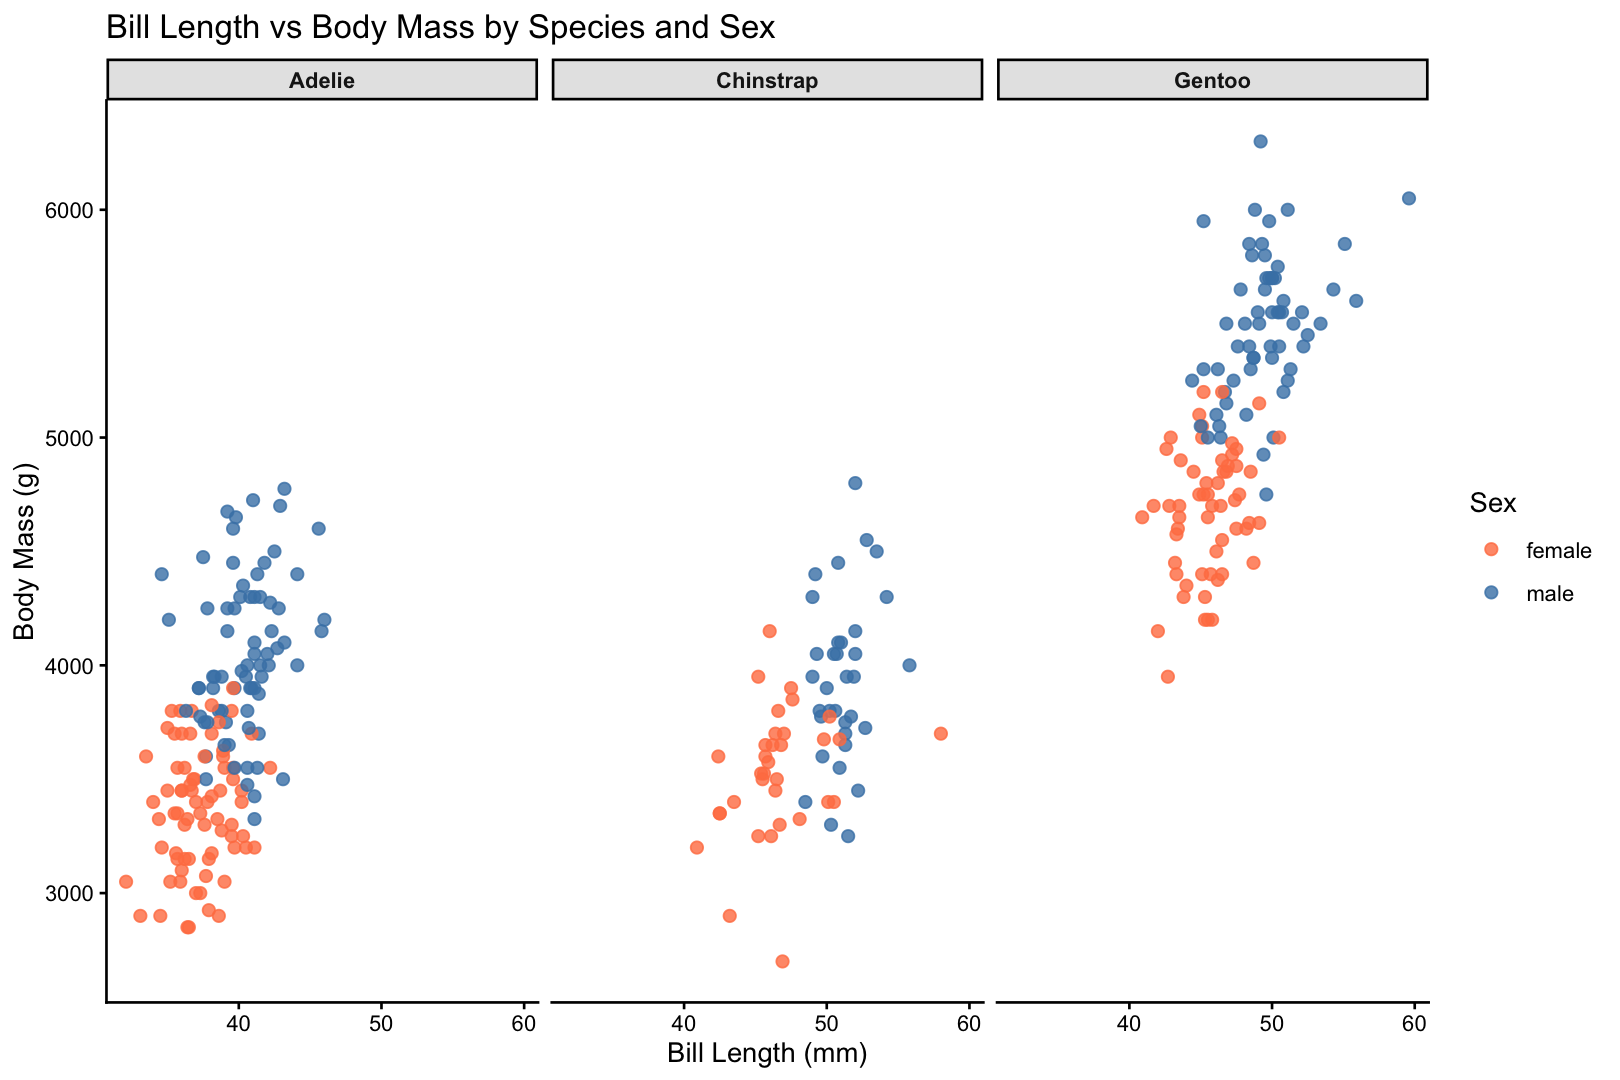

In [20]:
# facet_wrap() — wraps panels into a grid automatically
ggplot(penguins_complete, aes(x = bill_length_mm, y = body_mass_g,
                              colour = sex)) +
  geom_point(size = 2, alpha = 0.8) +
  facet_wrap(~ species, nrow = 1) +
  scale_colour_manual(values = c("female" = "coral", "male" = "steelblue")) +
  labs(x = "Bill Length (mm)", y = "Body Mass (g)",
       colour = "Sex",
       title  = "Bill Length vs Body Mass by Species and Sex") +
  theme_classic() +
  theme(strip.background = element_rect(fill = "grey90"),
        strip.text       = element_text(face = "bold"))

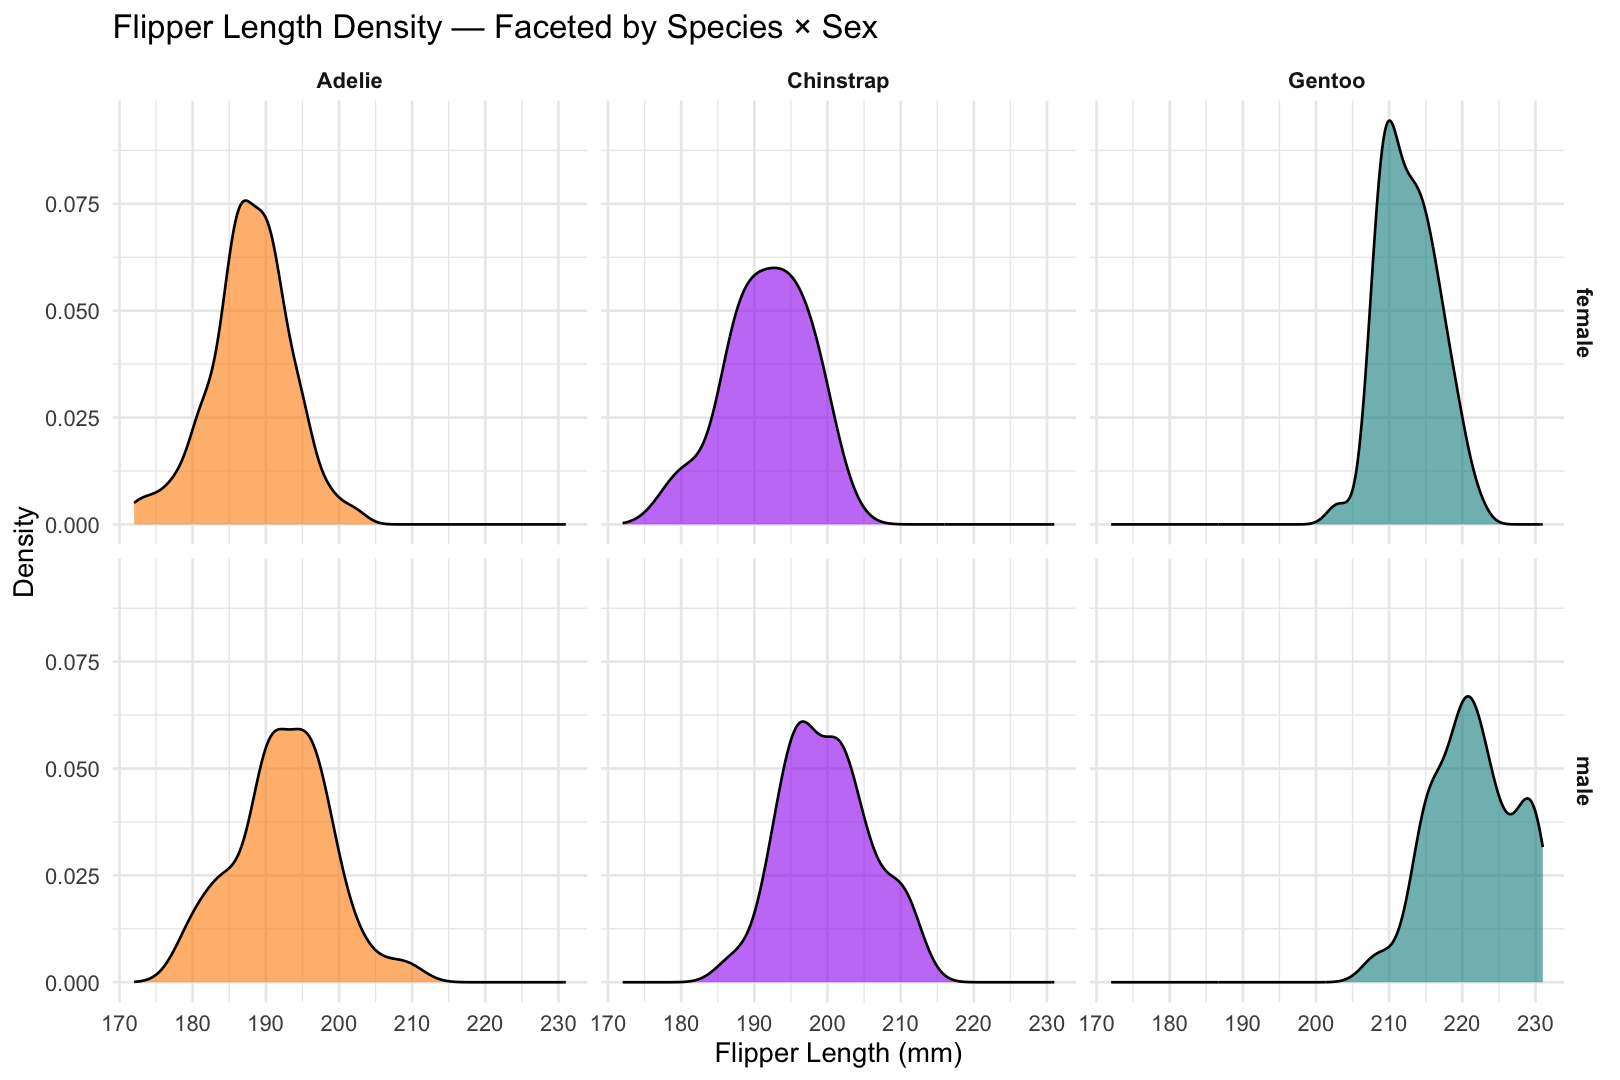

In [21]:
# facet_grid() — rows AND columns of grouping
ggplot(penguins_complete, aes(x = flipper_length_mm, fill = species)) +
  geom_density(alpha = 0.6) +
  facet_grid(sex ~ species) +
  scale_fill_manual(values = c("darkorange", "purple", "cyan4")) +
  labs(x = "Flipper Length (mm)", y = "Density",
       title = "Flipper Length Density — Faceted by Species × Sex") +
  theme_minimal() +
  theme(legend.position = "none",
        strip.text      = element_text(face = "bold"))

---
## Scales

**Scales** control the mapping between data values and visual properties. Every aesthetic has a corresponding `scale_*()` function.

Loading required package: viridisLite



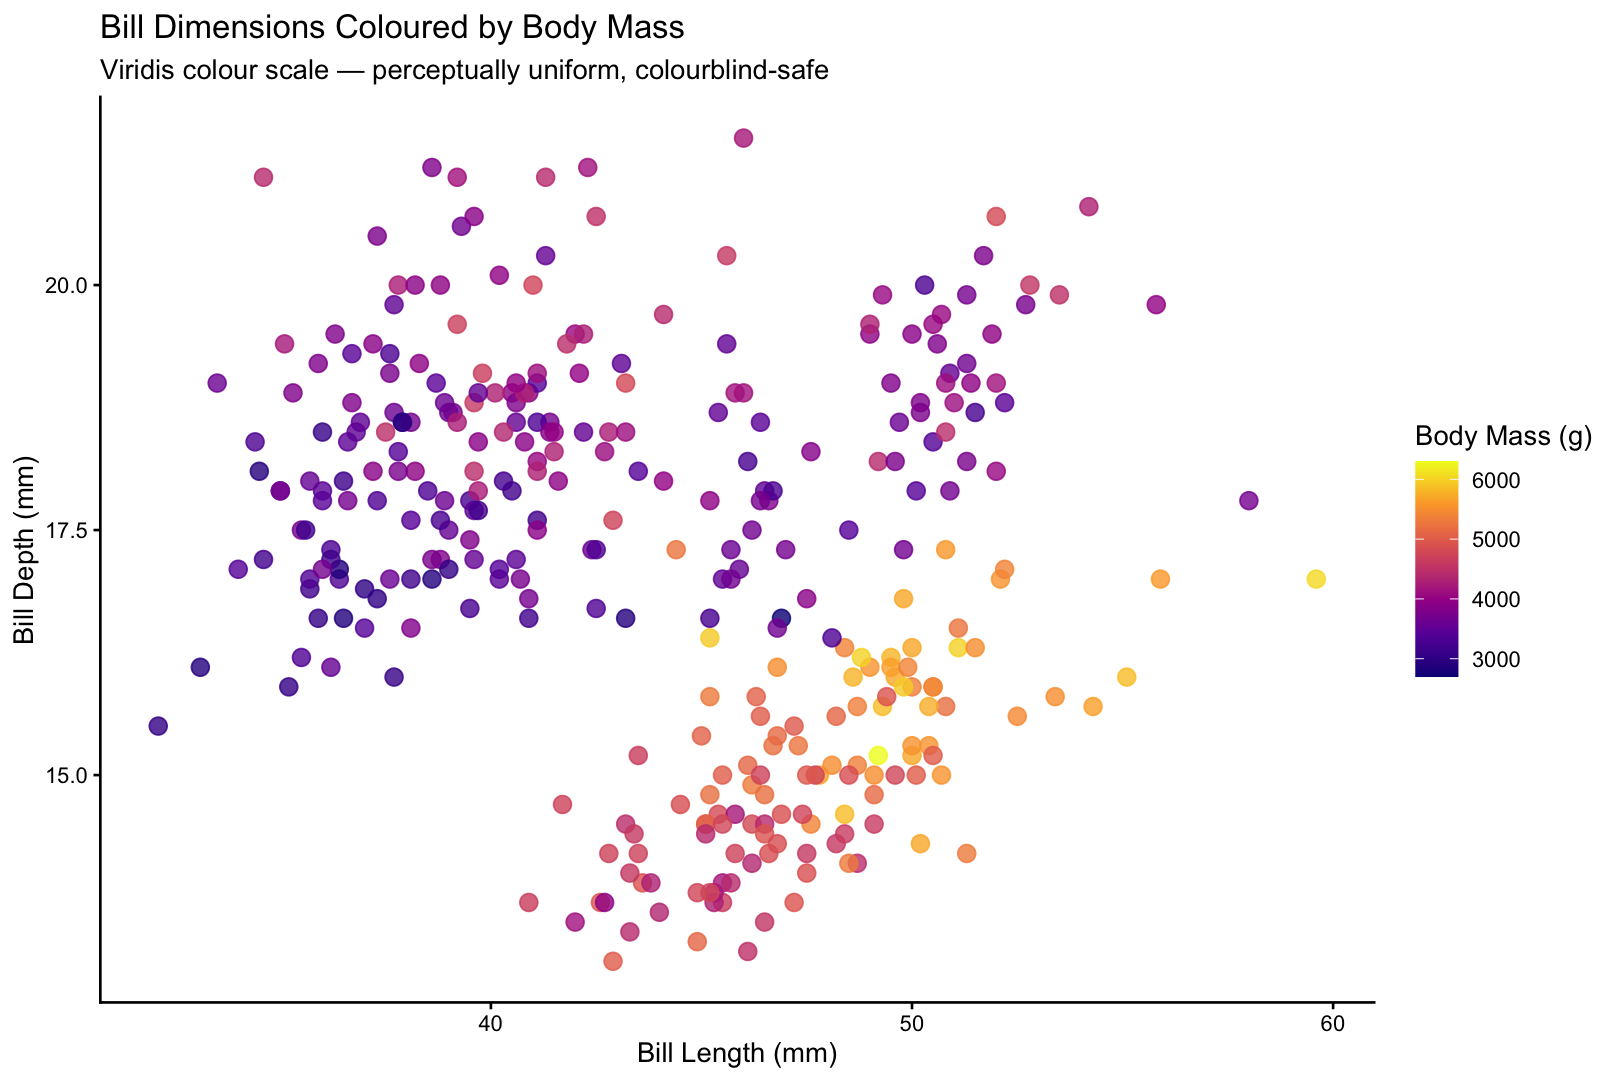

In [22]:
# Colour scales — viridis is perceptually uniform and colourblind-safe
# install.packages("viridis")
library(viridis)

ggplot(penguins_complete, aes(x = bill_length_mm, y = bill_depth_mm,
                              colour = body_mass_g)) +
  geom_point(size = 3, alpha = 0.8) +
  scale_colour_viridis_c(option = "plasma", name = "Body Mass (g)") +
  labs(x = "Bill Length (mm)", y = "Bill Depth (mm)",
       title  = "Bill Dimensions Coloured by Body Mass",
       subtitle = "Viridis colour scale — perceptually uniform, colourblind-safe") +
  theme_classic()

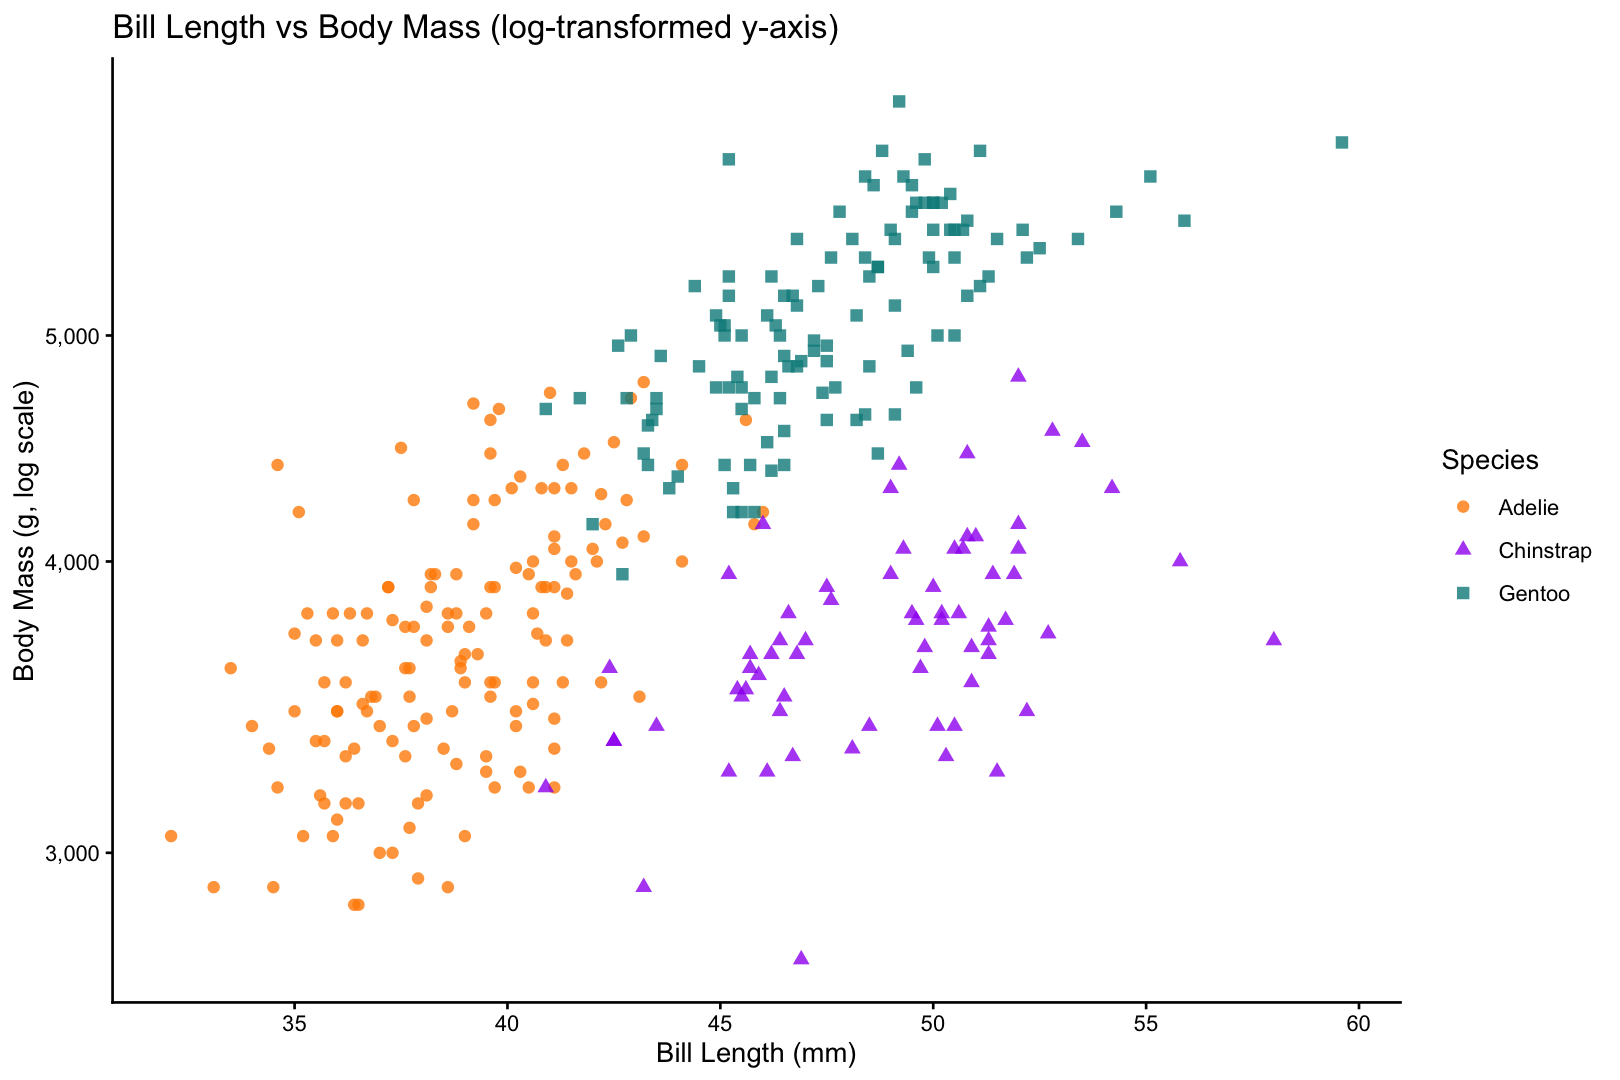

In [23]:
# Axis scales — log transform, breaks, limits
ggplot(penguins_complete, aes(x = bill_length_mm, y = body_mass_g,
                              colour = species, shape = species)) +
  geom_point(size = 2, alpha = 0.8) +
  scale_y_log10(labels = scales::comma) +   # log10 y-axis
  scale_x_continuous(breaks = seq(30, 60, by = 5)) +
  scale_colour_manual(values = c("darkorange", "purple", "cyan4")) +
  labs(x = "Bill Length (mm)", y = "Body Mass (g, log scale)",
       colour = "Species", shape = "Species",
       title = "Bill Length vs Body Mass (log-transformed y-axis)") +
  theme_classic()

---
## Themes — Fine-Tuning Appearance

`theme()` controls every non-data visual element: text size, font, axis lines, grid, margins, and more. `ggplot2` includes several preset themes; you can also build a custom theme.

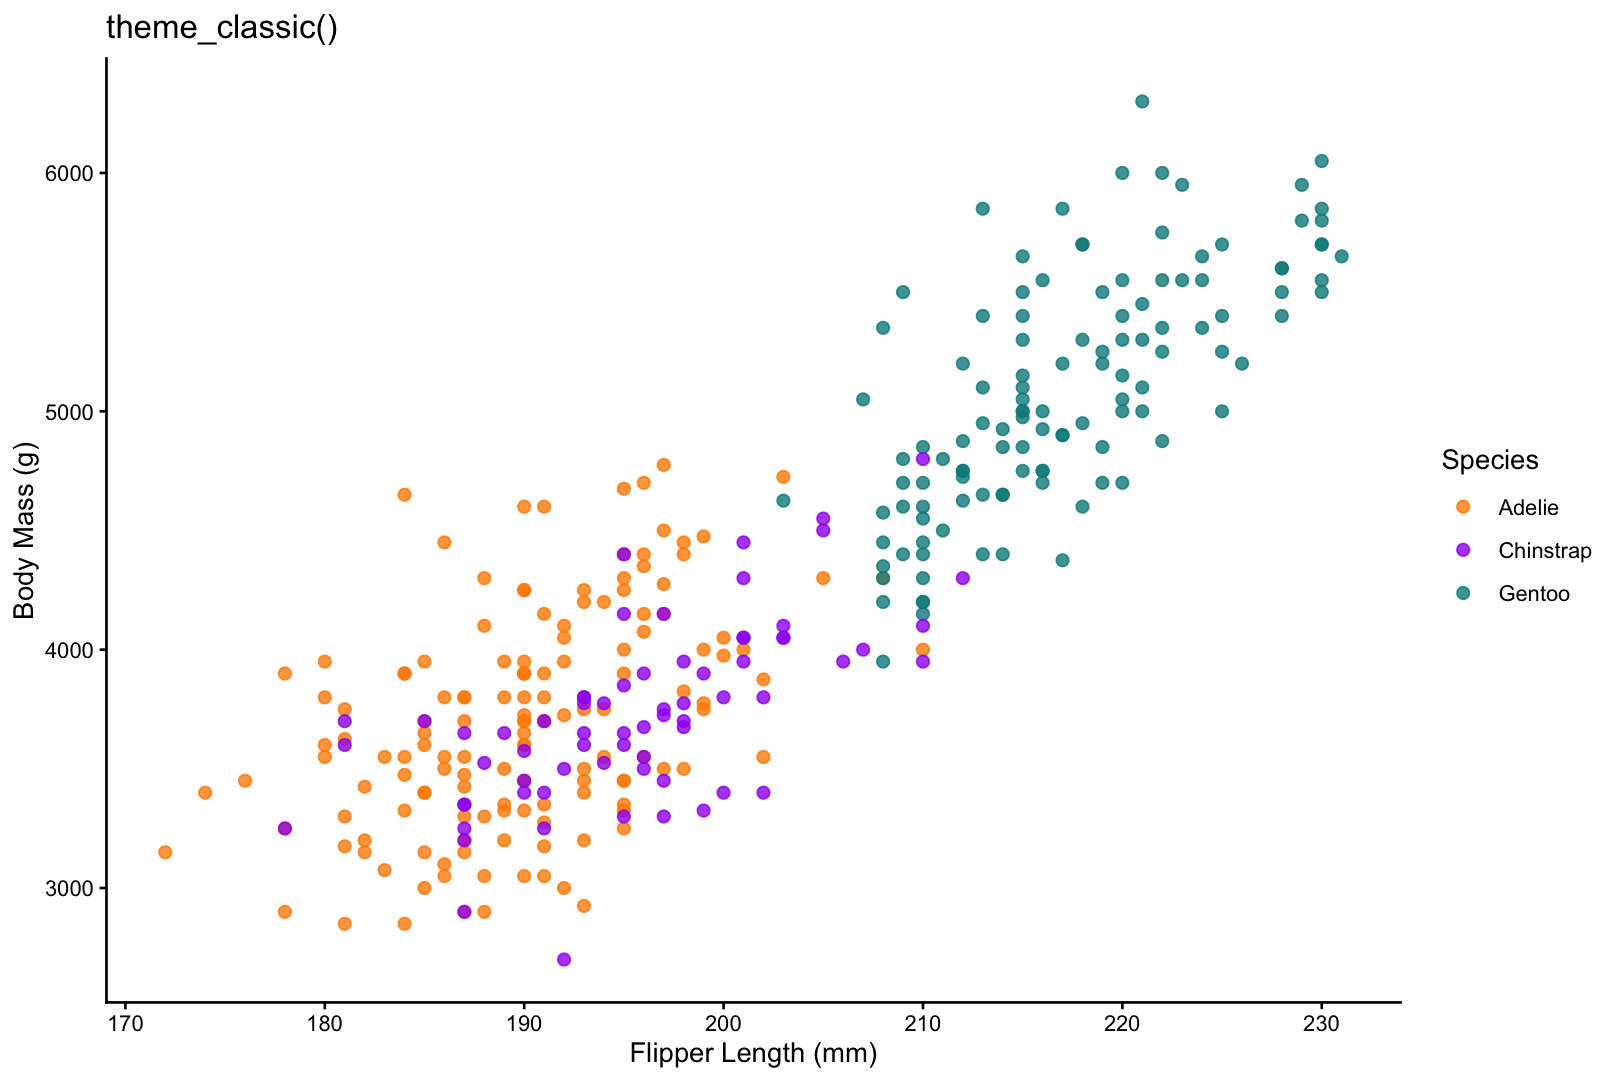

In [24]:
# Comparing preset themes on the same plot
base_plot <- ggplot(penguins_complete,
                    aes(x = flipper_length_mm, y = body_mass_g,
                        colour = species)) +
  geom_point(size = 2, alpha = 0.8) +
  scale_colour_manual(values = c("darkorange", "purple", "cyan4")) +
  labs(x = "Flipper Length (mm)", y = "Body Mass (g)",
       colour = "Species")

base_plot + theme_classic()  + labs(title = "theme_classic()")

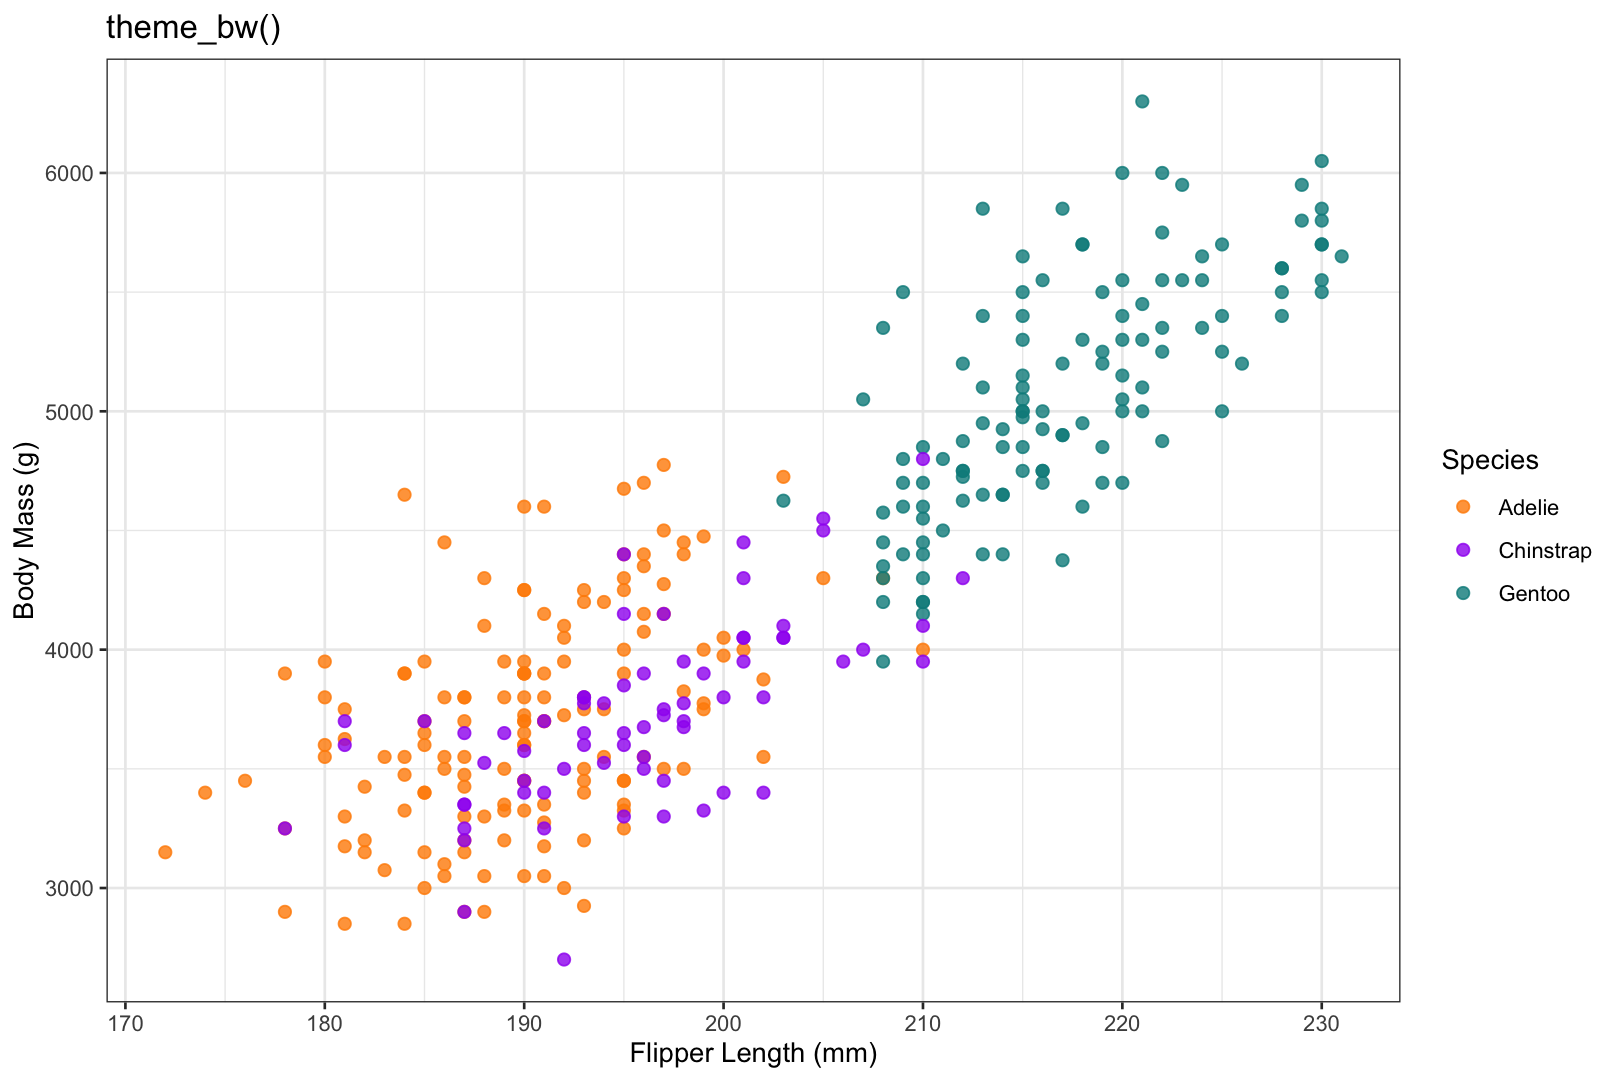

In [25]:
base_plot + theme_bw()       + labs(title = "theme_bw()")

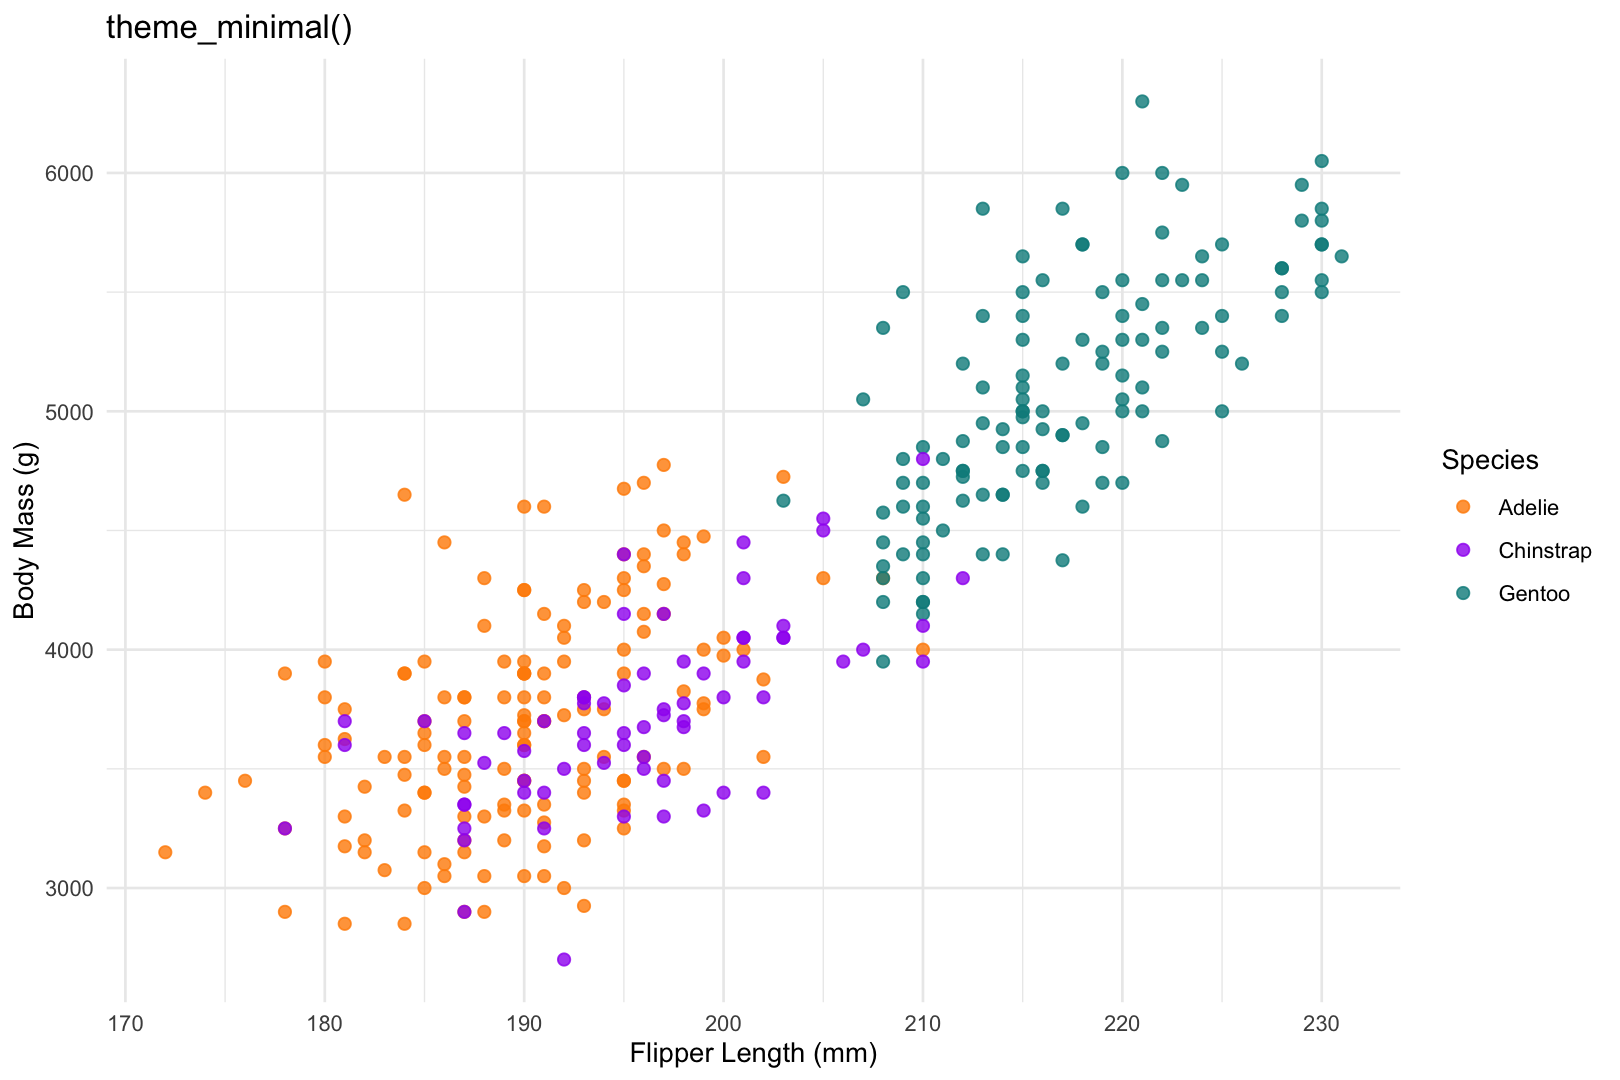

In [26]:
base_plot + theme_minimal()  + labs(title = "theme_minimal()")

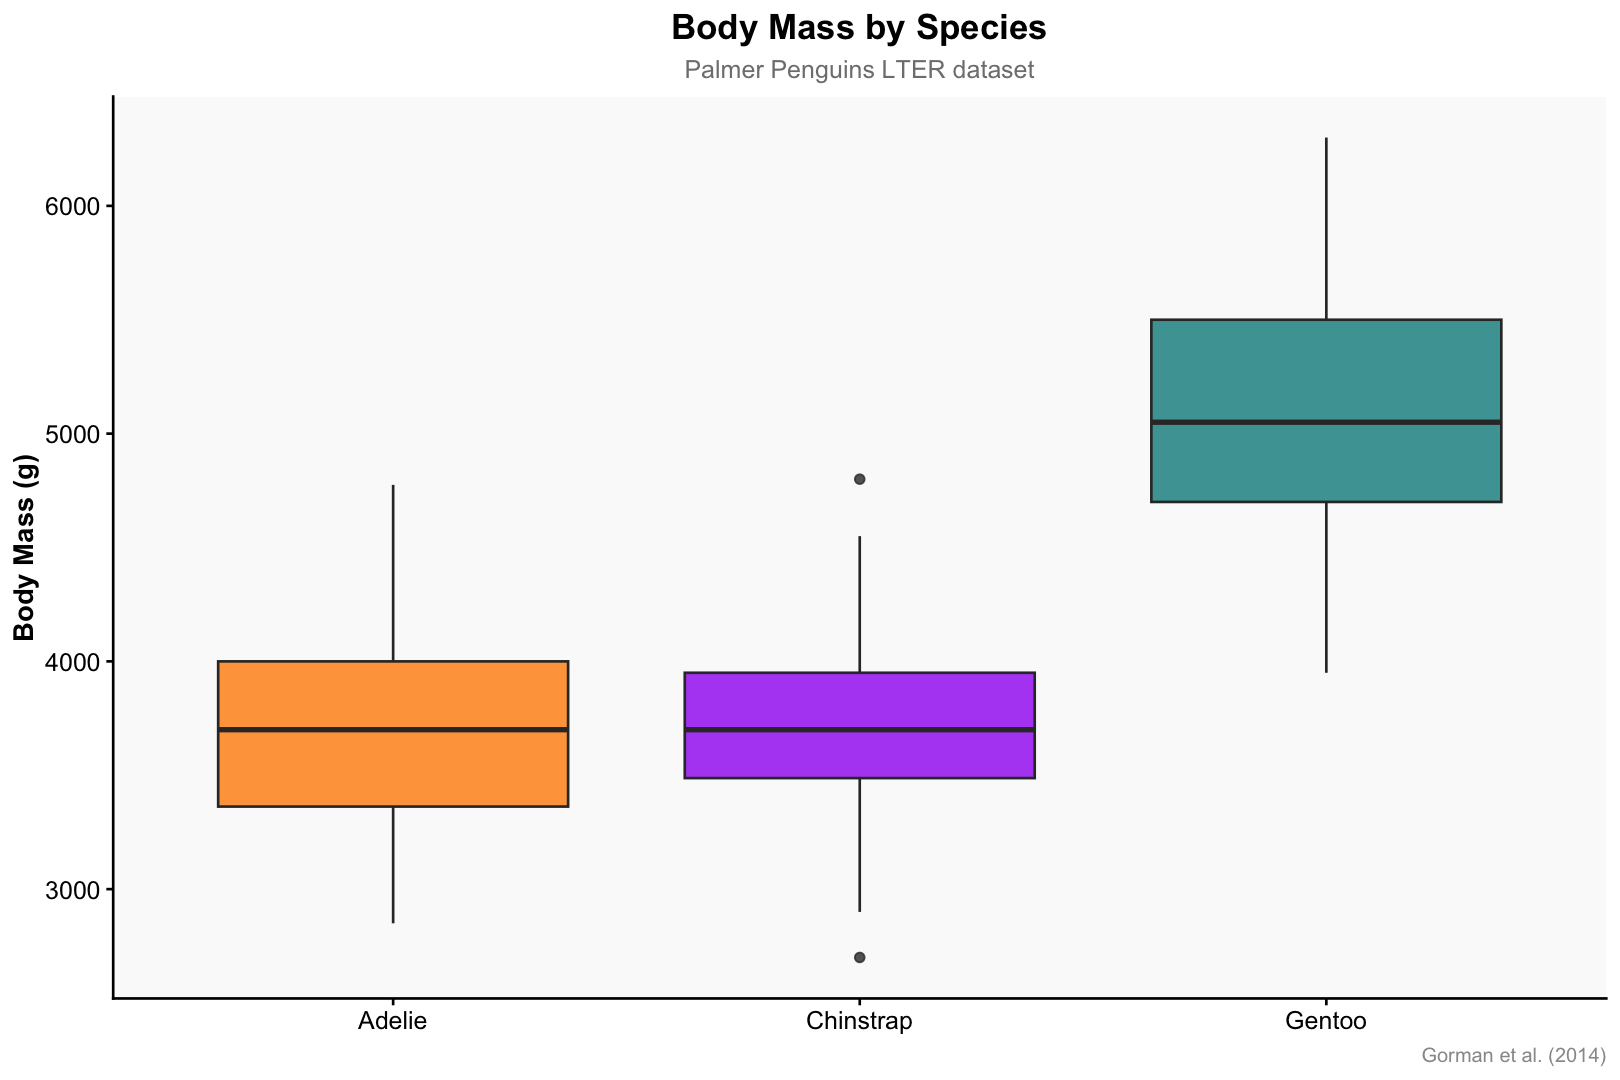

In [27]:
# Custom theme modifications with theme()
ggplot(penguins_complete,
       aes(x = species, y = body_mass_g, fill = species)) +
  geom_boxplot(alpha = 0.8) +
  scale_fill_manual(values = c("darkorange", "purple", "cyan4")) +
  labs(x = NULL, y = "Body Mass (g)",
       title    = "Body Mass by Species",
       subtitle = "Palmer Penguins LTER dataset",
       caption  = "Gorman et al. (2014)") +
  theme_classic() +
  theme(
    # Title formatting
    plot.title     = element_text(size = 14, face = "bold", hjust = 0.5),
    plot.subtitle  = element_text(size = 10, colour = "grey50", hjust = 0.5),
    plot.caption   = element_text(size = 8,  colour = "grey60"),

    # Axis text
    axis.title.y   = element_text(size = 11, face = "bold"),
    axis.text      = element_text(size = 10),

    # Legend
    legend.position = "none",    # remove redundant legend

    # Background
    plot.background  = element_rect(fill = "white", colour = NA),
    panel.background = element_rect(fill = "grey98", colour = NA)
  )

---
## Annotations and Labels

Effective scientific figures label key features directly, reducing the cognitive load of consulting a legend.

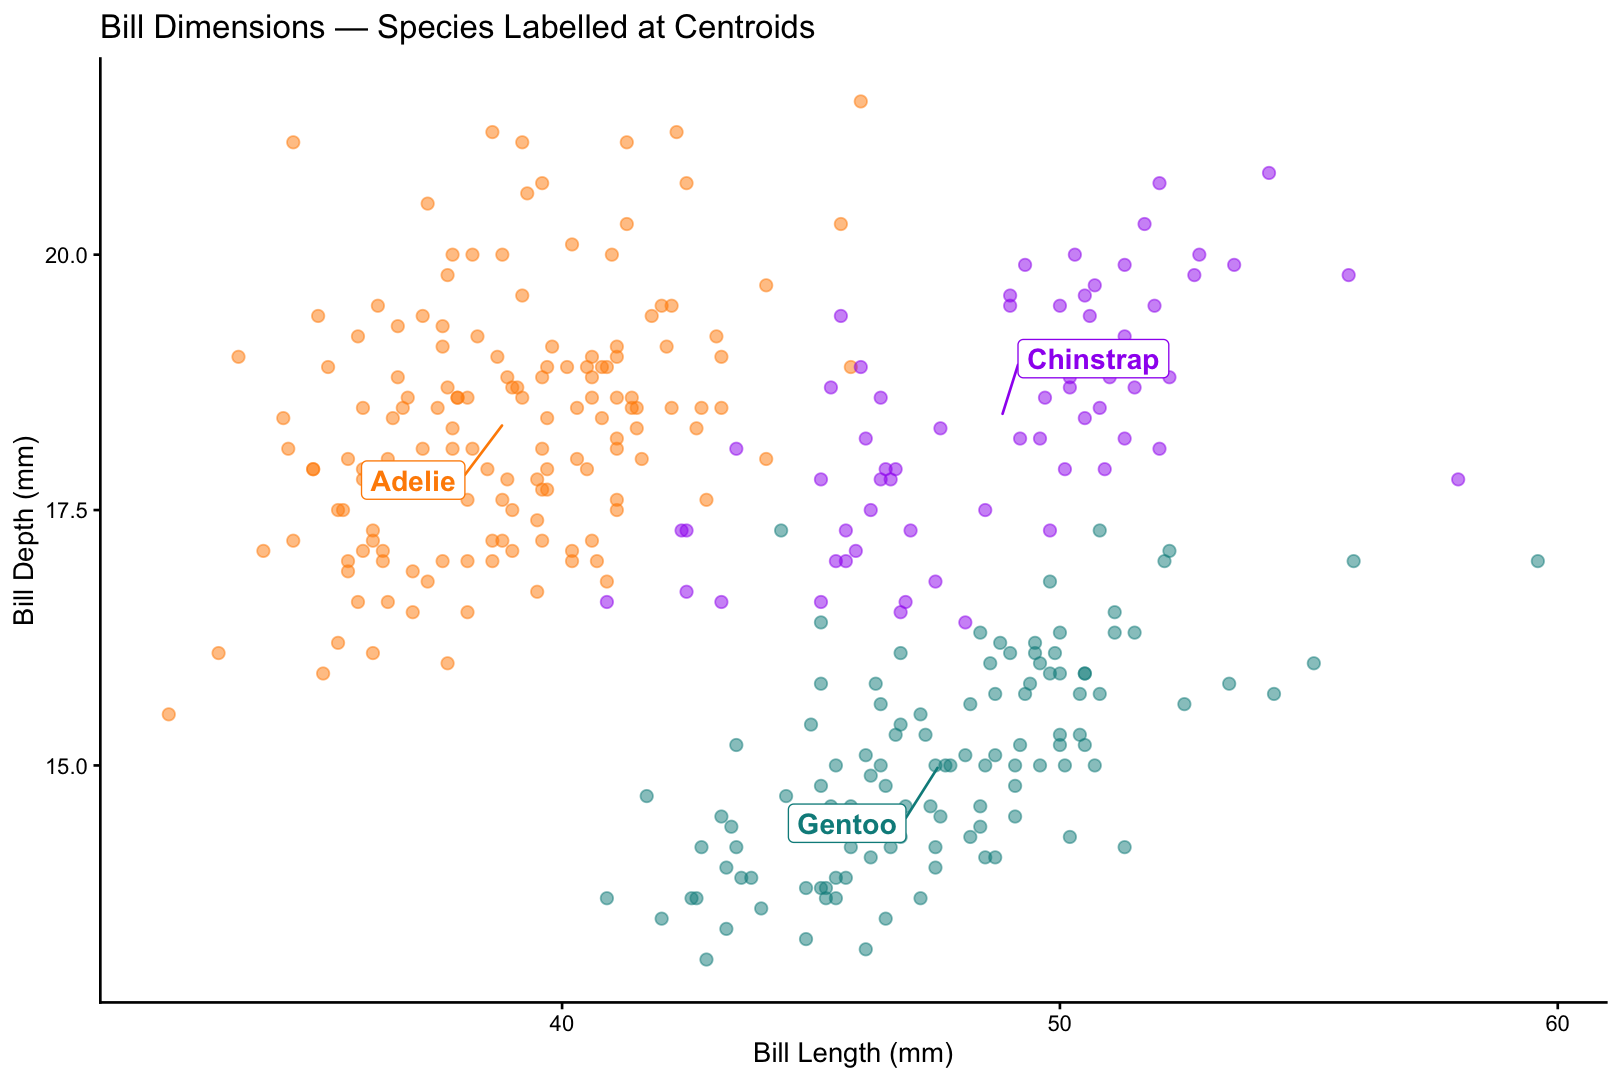

In [28]:
library(ggrepel)   # install.packages("ggrepel") — non-overlapping text labels

# Compute species centroids for labelling
species_centroids <- penguins_complete |>
  group_by(species) |>
  summarise(
    bill_length_mm = mean(bill_length_mm),
    bill_depth_mm  = mean(bill_depth_mm)
  )

ggplot(penguins_complete,
       aes(x = bill_length_mm, y = bill_depth_mm, colour = species)) +
  geom_point(size = 2, alpha = 0.5) +
  geom_label_repel(
    data    = species_centroids,
    aes(label = species),
    size    = 4,
    fontface= "bold",
    box.padding = 1,
    show.legend = FALSE
  ) +
  scale_colour_manual(values = c("darkorange", "purple", "cyan4")) +
  labs(x = "Bill Length (mm)", y = "Bill Depth (mm)",
       title = "Bill Dimensions — Species Labelled at Centroids") +
  theme_classic() +
  theme(legend.position = "none")

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


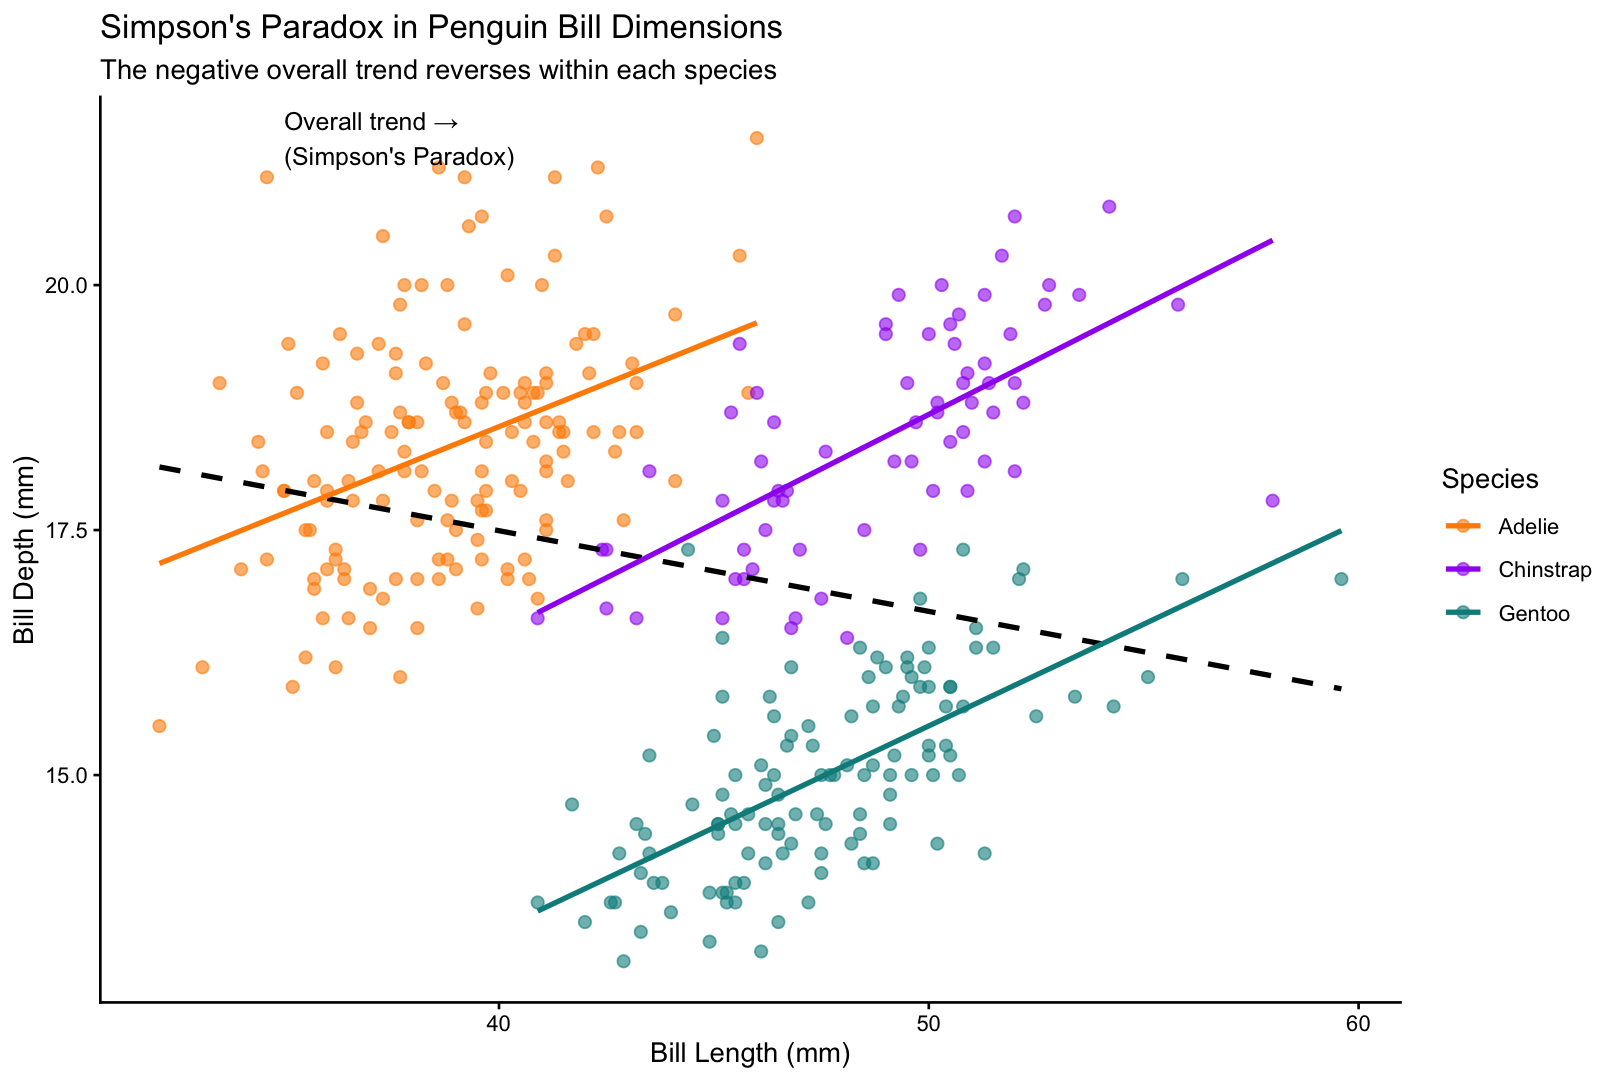

In [29]:
# Annotate with geom_text — note the Simpson's Paradox!
# The overall trend is negative, but within species it is positive
ggplot(penguins_complete,
       aes(x = bill_length_mm, y = bill_depth_mm)) +
  geom_point(aes(colour = species), size = 2, alpha = 0.6) +
  geom_smooth(method = "lm", colour = "black", linetype = "dashed",
              se = FALSE) +     # overall trend (misleading without grouping)
  geom_smooth(aes(colour = species), method = "lm",
              se = FALSE) +     # within-species trends
  scale_colour_manual(values = c("darkorange", "purple", "cyan4")) +
  annotate("text", x = 35, y = 21.5,
           label = "Overall trend →\n(Simpson's Paradox)",
           colour = "black", size = 3.5, hjust = 0) +
  labs(x = "Bill Length (mm)", y = "Bill Depth (mm)",
       colour = "Species",
       title = "Simpson's Paradox in Penguin Bill Dimensions",
       subtitle = "The negative overall trend reverses within each species") +
  theme_classic()

---
## Combining Plots with `patchwork`

`patchwork` (Pedersen, 2024) provides an elegant syntax for arranging multiple `ggplot2` objects into a single figure — essential for multi-panel publication figures.

`geom_smooth()` using formula = 'y ~ x'


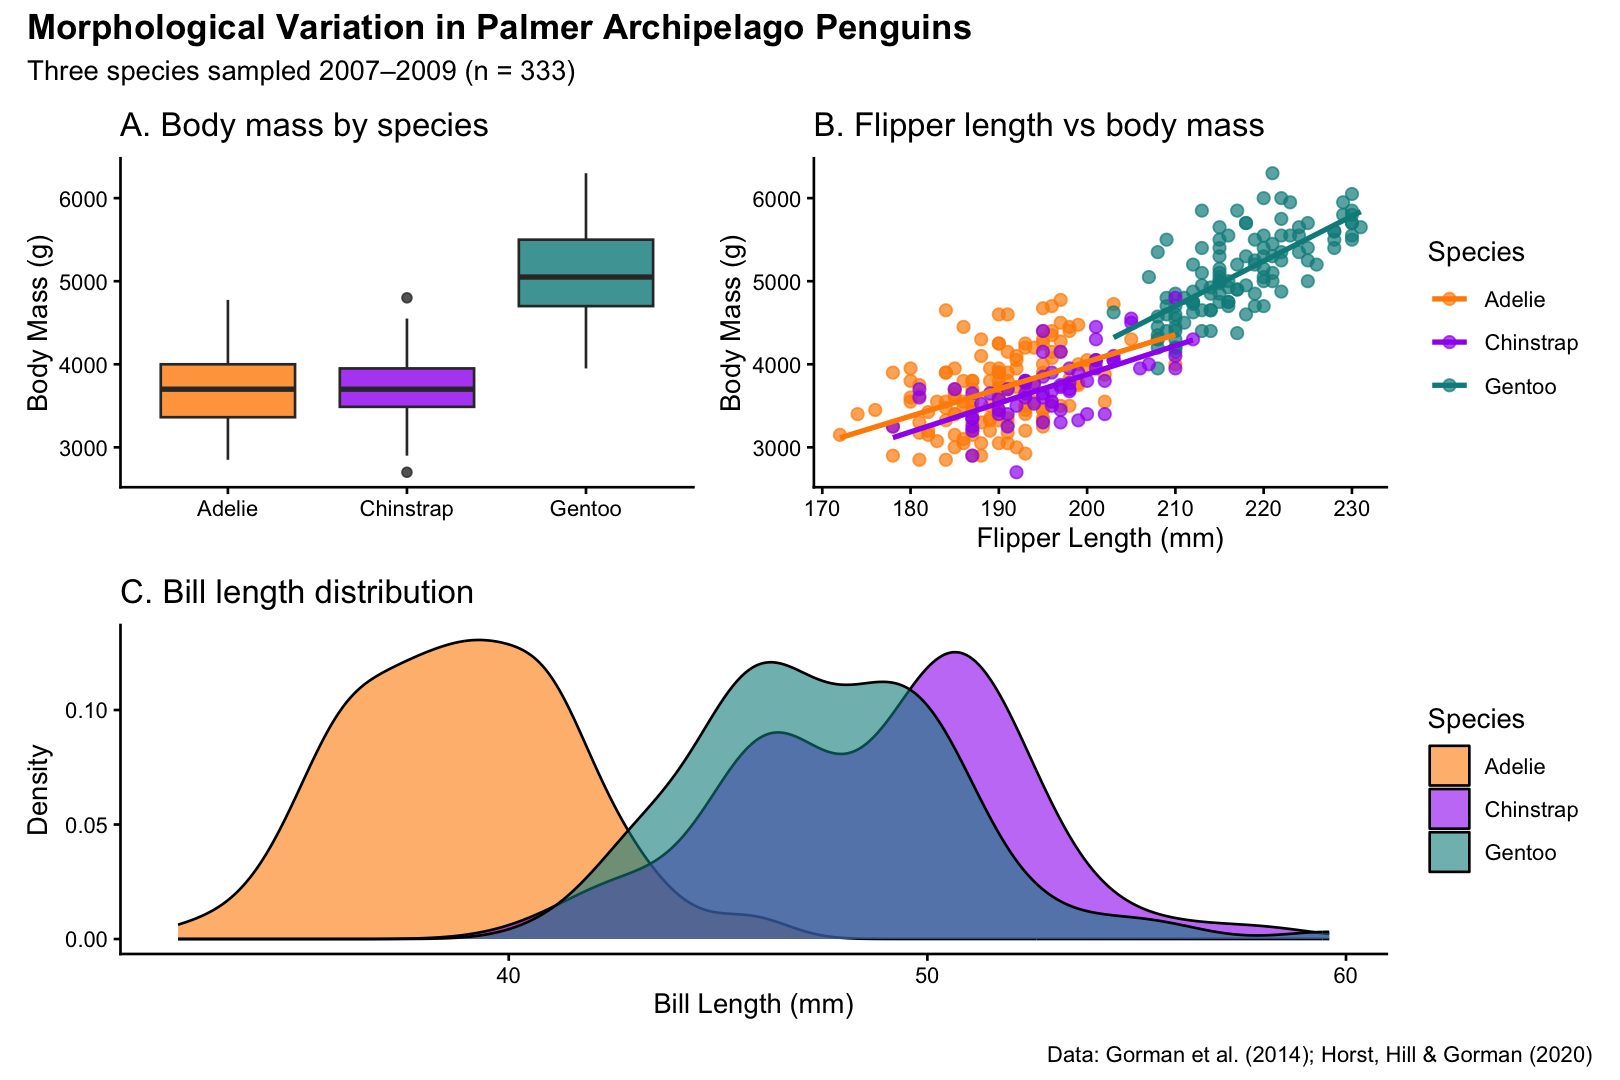

In [30]:
# install.packages("patchwork")
library(patchwork)

# Create component plots
p1 <- ggplot(penguins_complete, aes(x = species, y = body_mass_g, fill = species)) +
  geom_boxplot(alpha = 0.8) +
  scale_fill_manual(values = c("darkorange", "purple", "cyan4")) +
  labs(x = NULL, y = "Body Mass (g)", title = "A. Body mass by species") +
  theme_classic() + theme(legend.position = "none")

p2 <- ggplot(penguins_complete, aes(x = flipper_length_mm, y = body_mass_g,
                                     colour = species)) +
  geom_point(size = 2, alpha = 0.7) +
  geom_smooth(method = "lm", se = FALSE) +
  scale_colour_manual(values = c("darkorange", "purple", "cyan4")) +
  labs(x = "Flipper Length (mm)", y = "Body Mass (g)",
       colour = "Species", title = "B. Flipper length vs body mass") +
  theme_classic()

p3 <- ggplot(penguins_complete, aes(x = bill_length_mm, fill = species)) +
  geom_density(alpha = 0.6) +
  scale_fill_manual(values = c("darkorange", "purple", "cyan4")) +
  labs(x = "Bill Length (mm)", y = "Density",
       fill = "Species", title = "C. Bill length distribution") +
  theme_classic()

# Arrange: p1 top-left, p2 top-right, p3 full width below
(p1 | p2) / p3 +
  plot_annotation(
    title    = "Morphological Variation in Palmer Archipelago Penguins",
    subtitle = "Three species sampled 2007–2009 (n = 333)",
    caption  = "Data: Gorman et al. (2014); Horst, Hill & Gorman (2020)",
    theme    = theme(plot.title = element_text(size = 14, face = "bold"))
  )

---
## Saving Figures

`ggsave()` saves the most recently rendered `ggplot2` figure (or a named plot object) to disk.

In [ ]:
# Best practice: save as an object first, then export
final_figure <- ggplot(penguins_complete,
       aes(x = bill_length_mm, y = bill_depth_mm,
           colour = species, shape = species)) +
  geom_point(size = 2.5, alpha = 0.8) +
  geom_smooth(method = "lm", se = TRUE, alpha = 0.15) +
  scale_colour_manual(values = c("darkorange", "purple", "cyan4")) +
  scale_shape_manual(values  = c(16, 17, 15)) +
  labs(x       = "Bill Length (mm)",
       y       = "Bill Depth (mm)",
       colour  = "Species",
       shape   = "Species",
       title   = "Bill Dimensions of Palmer Penguins",
       subtitle= "Linear fits with 95% confidence intervals",
       caption = "Data: Gorman et al. (2014); Horst, Hill & Gorman (2020)") +
  theme_classic() +
  theme(plot.title = element_text(face = "bold"),
        legend.position = c(0.15, 0.80),
        legend.background = element_rect(fill = "white", colour = "grey80"))

# Save — PNG for sharing/web, PDF or SVG for publication (vector formats)
# ggsave("outputs/penguin_bill_dimensions.png",
#         final_figure, width = 9, height = 6, dpi = 300)

# ggsave("outputs/penguin_bill_dimensions.pdf",
#         final_figure, width = 9, height = 6)

print(final_figure)

---
## Raincloud Plots — Advanced Visualisation

A **raincloud plot** combines three views into one figure: the raw data points (the "rain"), a distribution estimate (the "cloud"), and a summary boxplot. Proposed by Allen et al. (2019) as a best-practice alternative to bar charts for showing full distributional data.

We use `ggdist` (Kay, 2024) for the distribution components.

**Reference:** Allen, M., Poggiali, D., Whitaker, K., Marshall, T.R. & Kievit, R.A. (2019). Raincloud plots: a multi-platform tool for robust data visualization. *Wellcome Open Research*, 4, 63. https://doi.org/10.12688/wellcomeopenres.15191.1

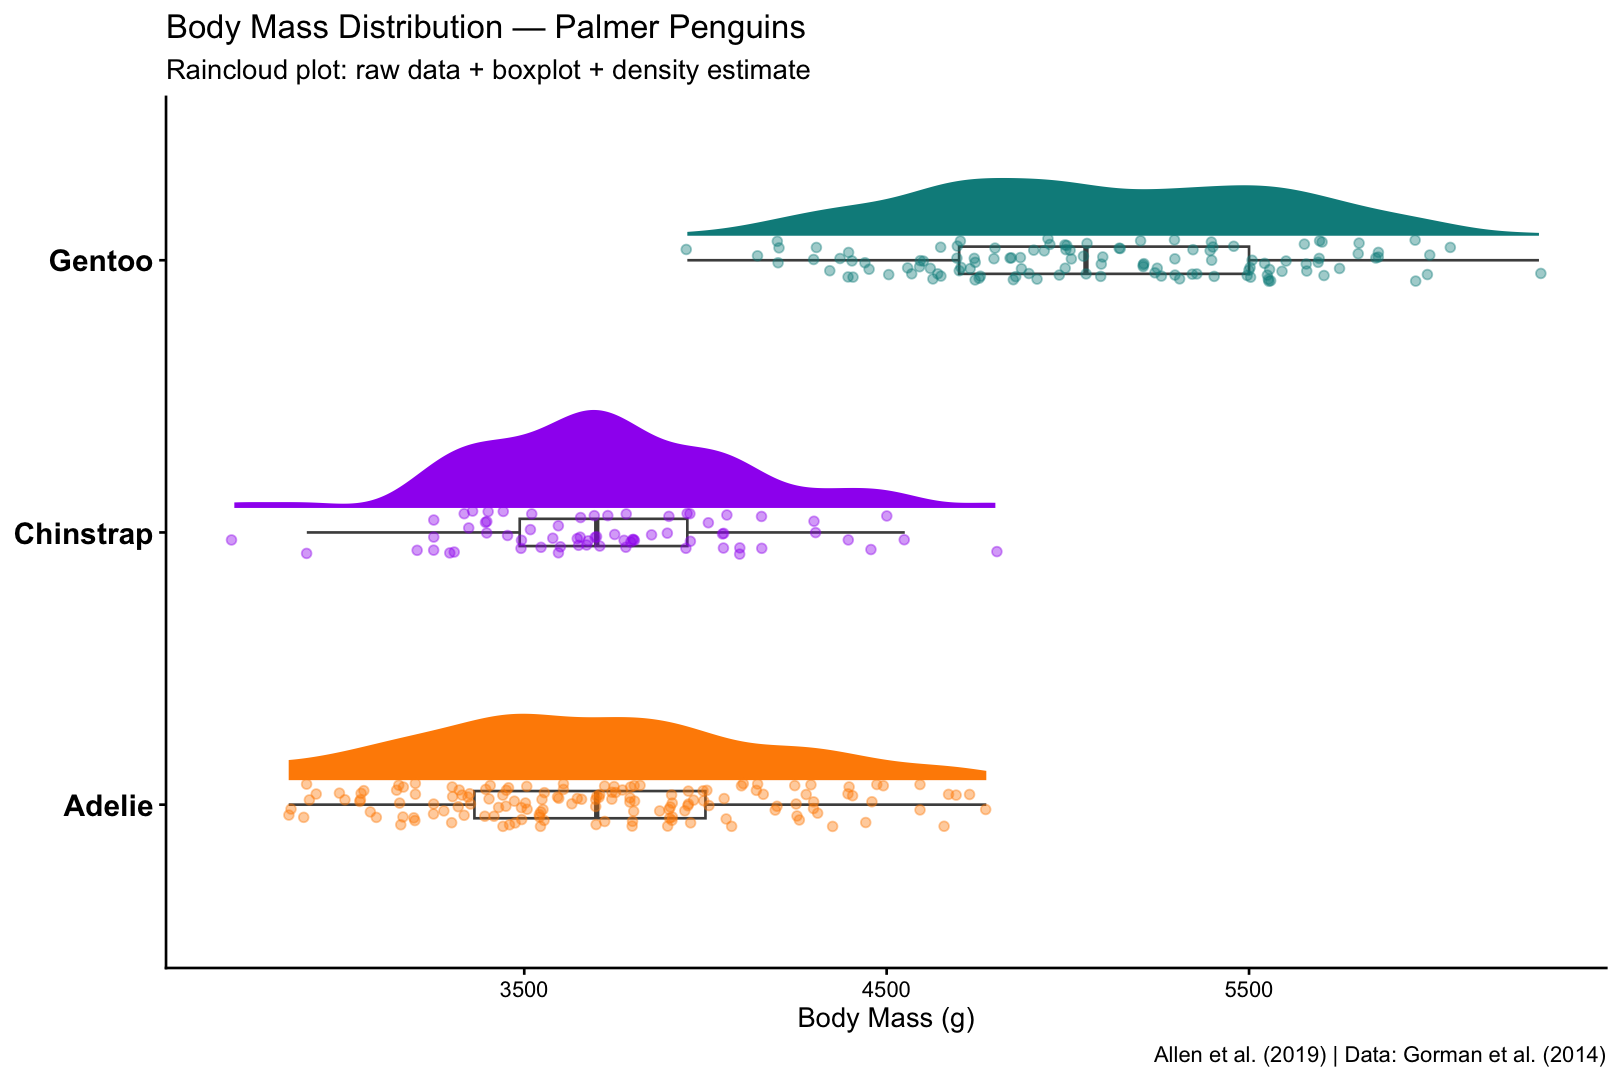

In [31]:
# install.packages("ggdist")
library(ggdist)

ggplot(penguins_complete,
       aes(x = species, y = body_mass_g, fill = species, colour = species)) +

  # 1. The "cloud": half-eye (density curve)
  stat_halfeye(
    adjust         = 0.6,
    width          = 0.4,
    justification  = -0.25,
    .width         = 0,
    point_colour   = NA
  ) +

  # 2. The boxplot (compact summary)
  geom_boxplot(
    width         = 0.1,
    outlier.shape = NA,
    fill          = "white",
    alpha         = 0.8,
    colour        = "grey30"
  ) +

  # 3. The "rain": jittered raw data
  geom_point(
    position = position_jitter(seed = 42, width = 0.08),
    size     = 1.5,
    alpha    = 0.4
  ) +

  # Flip for readability
  coord_flip() +

  scale_fill_manual(values   = c("darkorange", "purple", "cyan4")) +
  scale_colour_manual(values = c("darkorange", "purple", "cyan4")) +

  labs(x = NULL, y = "Body Mass (g)",
       title    = "Body Mass Distribution — Palmer Penguins",
       subtitle = "Raincloud plot: raw data + boxplot + density estimate",
       caption  = "Allen et al. (2019) | Data: Gorman et al. (2014)") +

  theme_classic() +
  theme(legend.position = "none",
        axis.text.y     = element_text(size = 12, face = "bold"))

---

## Summary

In this page, you have learned:

- How **base R graphics** (`graphics` package) work for quick exploratory plots — histograms, scatter plots, box plots, bar plots, and density curves.
- Why `ggplot2` improves on base R through a principled **grammar of graphics**.
- How to **build a ggplot2 figure layer by layer**, demonstrating that every added line contributes exactly one visual feature.
- How to use the most common **geometries** (`geom_point`, `geom_line`, `geom_histogram`, `geom_density`, `geom_boxplot`, `geom_violin`, `geom_bar`, `geom_smooth`).
- How to use **faceting** (`facet_wrap`, `facet_grid`) to create small-multiple figures.
- How to control **scales**, **themes**, and **annotations**.
- How to combine multiple plots with **`patchwork`**.
- How to save figures with **`ggsave()`**.
- How to construct **raincloud plots** with `ggdist`.

---

## References

- Allen, M. et al. (2019). Raincloud plots. *Wellcome Open Research*, 4, 63.
- Gorman, K.B., Williams, T.D. & Fraser, W.R. (2014). *PLOS ONE*, 9(3), e90081.
- Horst, A.M., Hill, A.P. & Gorman, K.B. (2020). *palmerpenguins*. https://doi.org/10.5281/zenodo.3960218
- Kay, M. (2024). *ggdist: Visualizations of Distributions and Uncertainty*. https://mjskay.github.io/ggdist/
- Pedersen, T.L. (2024). *patchwork: The Composer of Plots*. https://patchwork.data-imaginist.com
- Tufte, E.R. (1983). *The Visual Display of Quantitative Information*. Graphics Press.
- Tukey, J.W. (1977). *Exploratory Data Analysis*. Addison-Wesley.
- Wickham, H. (2010). A layered grammar of graphics. *Journal of Computational and Graphical Statistics*, 19(1), 3–28.
- Wickham, H. (2016). *ggplot2: Elegant Graphics for Data Analysis* (2nd ed.). Springer.
- Wilkinson, L. (2005). *The Grammar of Graphics* (2nd ed.). Springer.